# Solution Part:
* Data Understanding
* Data Exploration
* Data Cleaning
* Data Preparation/Feature Engineering
* Model Building
* Model Evaluation

In [1]:
#Import all the libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
pd.set_option('display.max_rows', None)

In [5]:
#Read the dataset
cars = pd.read_parquet('Customer Database.parquet')
cars_test = pd.read_excel('Test Customer Data.xlsx')
cars_test_original = cars_test.copy()

In [6]:
cars.shape

(4747051, 36)

In [7]:
cars.head()

,Location_Region,VRLOCATION,VRSALEAMT,VRMILEAGE,Vehicle_year,Trim,Series,Vehicle_cylinders,Vehicle_botcolor,Vehicle_doors,Vehicle_trantype,Vehicle_engine,Vehicle_drive,Vehicle_condition_drivable,Vehicle_condition_overall,BodyClass,DriveType,EngineHP,FuelTypePrimary,EngineConfiguration,EngineModel,GVWR,PlantCountry,BasePrice,IsEV,EVType,MarketSegment,SALEDATE_WeekofYearNumber,SALEDATE_MonthofYearNumber,SALEDATE_Quarter,SALEDATE_Year,Model,Make,VRSALEDATE,VRLIGHTS,Misc_SalesChannel
0,EAST,CHARLESTON,1900,4573,2017,None,4 passenger,1.0,BLU,2.0,A,1.0,R,Y,5.0,Low Speed Vehicle (LSV) / Neighborhood Electri...,None,NaN,None,None,None,"Class 1A: 3,000 lb or less (1,360 kg or less)",UNITED STATES (USA),NaN,0.0,ICE,Other,1,1,4.0,2025,2Five,E-Z-GO DIVISION OF TEXTRON,20250110,R,SIMULCAST
1,WEST,SANANTONIO,4000,12192,1987,None,Integral with body cab,NaN,YEL,NaN,A,0.7,R,Y,4.0,Truck,6x6,NaN,None,V-Shaped,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,17,4,NaN,2022,Speciality Vehicle,OSHKOSH,20220426,R,IN LANE
2,WEST,HOUSTON,2900,84304,1984,None,V - Series,8.0,TEA,NaN,I,10.4,R,Y,3.0,Incomplete,4x2,250.0,None,V-Shaped,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,32,8,NaN,2022,Speciality Vehicle,OSHKOSH,20220811,R,IN LANE
3,NORTH,CHICAGO,3250,34505,2018,None,None,NaN,WHT,NaN,A,NaN,R,Y,3.0,None,None,NaN,None,None,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,20,5,NaN,2021,None,HENDRICKSON,20210519,R,SIMULCAST
4,SOUTH,BIRMINGHAM,10000,52756,2002,None,None,6.0,WHT,NaN,A,5.9,R,Y,4.0,Truck-Tractor,None,NaN,Diesel,In-Line,B Series,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,34,8,NaN,2020,CYT 30,KALMAR INDUSTRIES LLC,20200826,None,IN LANE


In [8]:
# cars.sort_values(by=['Make', 'Model','Trim','Vehicle_year','Vehicle_cylinders'], ascending=[True, True, True, False, True], inplace=True)
# cars[['Make', 'Model', 'VRSALEAMT', 'VRMILEAGE', 'Vehicle_year', 'Trim', 'Vehicle_cylinders']].head(1000)

Data Exploration

In [9]:
import numpy as np
import pandas as pd

def clean_and_fix_temporal(df, k_smooth=100, drop_vrlights=True):
    """
    Cleaning + feature fixes.
    - Fill missing Vehicle_condition_overall using VRLIGHTS (universal mapping; no last-N-days window)
    - Keep final column name Vehicle_condition_overall (fill in-place)
    - Smarter categorical missing handling:
        * Use "Not Applicable" only when concept truly doesn't apply (mostly EV vs ICE logic)
        * Otherwise use "Unknown"
    """

    df = df.copy()

    # -------------------------
    # 1) Parse sale date + basic temporal fields
    # -------------------------
    if "VRSALEDATE" in df.columns:
        df["sale_date"] = pd.to_datetime(df["VRSALEDATE"].astype(str), format="%Y%m%d", errors="coerce")
    else:
        df["sale_date"] = pd.NaT

    # Ensure SALEDATE_ fields numeric (if present)
    for c in ["SALEDATE_Year", "SALEDATE_MonthofYearNumber", "SALEDATE_WeekofYearNumber", "SALEDATE_Quarter"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Derive missing SALEDATE components from sale_date
    if "sale_date" in df.columns and df["sale_date"].notna().any():
        if "SALEDATE_Year" not in df.columns:
            df["SALEDATE_Year"] = df["sale_date"].dt.year
        else:
            df["SALEDATE_Year"] = df["SALEDATE_Year"].fillna(df["sale_date"].dt.year)

        if "SALEDATE_MonthofYearNumber" not in df.columns:
            df["SALEDATE_MonthofYearNumber"] = df["sale_date"].dt.month
        else:
            df["SALEDATE_MonthofYearNumber"] = df["SALEDATE_MonthofYearNumber"].fillna(df["sale_date"].dt.month)

        if "SALEDATE_Quarter" not in df.columns:
            df["SALEDATE_Quarter"] = df["sale_date"].dt.quarter
        else:
            df["SALEDATE_Quarter"] = df["SALEDATE_Quarter"].fillna(df["sale_date"].dt.quarter)

        if "SALEDATE_WeekofYearNumber" not in df.columns:
            try:
                df["SALEDATE_WeekofYearNumber"] = df["sale_date"].dt.isocalendar().week.astype("float")
            except Exception:
                df["SALEDATE_WeekofYearNumber"] = np.nan
        else:
            try:
                df["SALEDATE_WeekofYearNumber"] = df["SALEDATE_WeekofYearNumber"].fillna(
                    df["sale_date"].dt.isocalendar().week.astype("float")
                )
            except Exception:
                pass

    # -------------------------
    # 2) IsEV cleanup (binary)
    # -------------------------
    if "IsEV" in df.columns:
        df["IsEV"] = pd.to_numeric(df["IsEV"], errors="coerce").fillna(0).clip(0, 1).astype(np.int8)
    else:
        # default: treat as not EV if column missing
        df["IsEV"] = 0

    # -------------------------
    # 3) Vehicle_condition_overall: extract numeric + missing flag
    # -------------------------
    if "Vehicle_condition_overall" in df.columns:
        vc = df["Vehicle_condition_overall"].astype(str).str.extract(r'(\d+(\.\d+)?)')[0]
        df["Vehicle_condition_overall"] = pd.to_numeric(vc, errors="coerce")
    else:
        df["Vehicle_condition_overall"] = np.nan

    df["Vehicle_condition_overall_missing"] = df["Vehicle_condition_overall"].isna().astype(np.int8)

    # -------------------------
    # 4) Fill missing condition using VRLIGHTS (universal smoothed-mean mapping)
    # -------------------------
    if "VRLIGHTS" in df.columns:
        lights = df["VRLIGHTS"].astype(str).str.strip().str.upper()

        known_mask = df["Vehicle_condition_overall"].notna() & lights.notna()

        global_mean = float(df.loc[df["Vehicle_condition_overall"].notna(), "Vehicle_condition_overall"].mean()) \
            if df["Vehicle_condition_overall"].notna().any() else 3.0

        if known_mask.any():
            stats = (
                pd.DataFrame({
                    "VRLIGHTS": lights.loc[known_mask],
                    "cond": df.loc[known_mask, "Vehicle_condition_overall"]
                })
                .groupby("VRLIGHTS")["cond"]
                .agg(["count", "mean"])
                .rename(columns={"count": "n", "mean": "mu"})
            )
            stats["mu_smooth"] = (stats["n"] * stats["mu"] + k_smooth * global_mean) / (stats["n"] + k_smooth)
            light_map = stats["mu_smooth"].to_dict()
        else:
            light_map = {}

        missing_mask = df["Vehicle_condition_overall"].isna()
        proxy = lights.map(light_map)

        df.loc[missing_mask, "Vehicle_condition_overall"] = proxy.loc[missing_mask]
        df["condition_imputed_from_lights"] = (missing_mask & proxy.notna()).astype(np.int8)

        df["Vehicle_condition_overall"] = df["Vehicle_condition_overall"].fillna(global_mean)

        if drop_vrlights:
            df = df.drop(columns=["VRLIGHTS"])
    else:
        df["condition_imputed_from_lights"] = 0

    # -------------------------
    # 5) Numeric coercions (core numeric columns)
    # -------------------------
    num_cols = [
        "VRMILEAGE", "Vehicle_year", "Vehicle_cylinders", "Vehicle_doors",
        "Vehicle_engine", "EngineHP", "BasePrice",
        "SALEDATE_WeekofYearNumber", "SALEDATE_MonthofYearNumber",
        "SALEDATE_Quarter", "SALEDATE_Year"
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Numeric "N/A" handling: sentinel + missing flags (helps XGB stability)
    for c in ["EngineHP", "BasePrice", "Vehicle_cylinders"]:
        if c in df.columns:
            df[f"{c}_missing"] = df[c].isna().astype(np.int8)
            df[c] = df[c].fillna(-1)

    # -------------------------
    # 6) Clamp year + vehicle_age at sale
    # -------------------------
    if "Vehicle_year" in df.columns:
        df["Vehicle_year"] = df["Vehicle_year"].clip(1900, 2100)

    if "SALEDATE_Year" in df.columns and "Vehicle_year" in df.columns:
        df["vehicle_age"] = (df["SALEDATE_Year"] - df["Vehicle_year"]).clip(lower=0)
    else:
        df["vehicle_age"] = np.nan

    # -------------------------
    # 7) Mileage hygiene + safe ratios/logs
    # -------------------------
    if "VRMILEAGE" in df.columns:
        df["VRMILEAGE"] = df["VRMILEAGE"].clip(lower=0)
        if df["VRMILEAGE"].notna().sum() > 50:
            cap = df["VRMILEAGE"].quantile(0.9995)
            df["VRMILEAGE"] = df["VRMILEAGE"].clip(upper=cap)

        age_safe = df["vehicle_age"].replace(0, 0.5)
        df["mileage_per_year"] = df["VRMILEAGE"] / age_safe
        df["log_mileage"] = np.log1p(df["VRMILEAGE"])
    else:
        df["mileage_per_year"] = np.nan
        df["log_mileage"] = np.nan

    df["log_age"] = np.log1p(df["vehicle_age"])

    # -------------------------
    # 8) Drivable flag
    # -------------------------
    if "Vehicle_condition_drivable" in df.columns:
        df["drivable_flag"] = (df["Vehicle_condition_drivable"].astype(str).str.upper() == "Y").astype(np.int8)
    else:
        df["drivable_flag"] = 0

    # -------------------------
    # 9) GVWR numeric class extraction + missing flag
    # -------------------------
    if "GVWR" in df.columns:
        gvwr_class = df["GVWR"].astype(str).str.extract(r"Class\s*(\d+)")[0]
        df["GVWR_class"] = pd.to_numeric(gvwr_class, errors="coerce")

    # -------------------------
    # 10) SMART categorical missing handling (EV-aware)
    # -------------------------
    # These generally apply to both EV and ICE. Missing means "Unknown", not "Not Applicable".
    unknown_if_missing = [
        "Trim", "Series", "FuelTypePrimary", "DriveType", "BodyClass",
        "MarketSegment", "Vehicle_trantype", "Vehicle_drive"
    ]
    for c in unknown_if_missing:
        if c in df.columns:
            df[c] = df[c].astype("object").fillna("Unknown")

    # EVType: Only applicable if IsEV==1
    if "EVType" in df.columns:
        df["EVType"] = df["EVType"].astype("object")
        df.loc[df["IsEV"] == 0, "EVType"] = df.loc[df["IsEV"] == 0, "EVType"].fillna("Not Applicable")
        df.loc[df["IsEV"] == 1, "EVType"] = df.loc[df["IsEV"] == 1, "EVType"].fillna("Unknown")

    # Engine descriptors: Often not applicable for EVs; unknown for ICE if missing
    for c in ["EngineConfiguration", "EngineModel"]:
        if c in df.columns:
            df[c] = df[c].astype("object")
            df.loc[df["IsEV"] == 1, c] = df.loc[df["IsEV"] == 1, c].fillna("Not Applicable")
            df.loc[df["IsEV"] == 0, c] = df.loc[df["IsEV"] == 0, c].fillna("Unknown")

    # These are process/status fields; keep your existing behavior
    for c in ["Vehicle_condition_crstatus", "Vehicle_condition_drivable"]:
        if c in df.columns:
            df[c] = df[c].astype("object").fillna("Unknown")

    # -------------------------
    # 11) Downcast numerics (optional)
    # -------------------------
    for c in df.select_dtypes(include=[np.number]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")

    return df

In [10]:
cars = clean_and_fix_temporal(cars)
cars_test = clean_and_fix_temporal(cars_test)

In [11]:
cars.head()

,Location_Region,VRLOCATION,VRSALEAMT,VRMILEAGE,Vehicle_year,Trim,Series,Vehicle_cylinders,Vehicle_botcolor,Vehicle_doors,Vehicle_trantype,Vehicle_engine,Vehicle_drive,Vehicle_condition_drivable,Vehicle_condition_overall,BodyClass,DriveType,EngineHP,FuelTypePrimary,EngineConfiguration,EngineModel,GVWR,PlantCountry,BasePrice,IsEV,EVType,MarketSegment,SALEDATE_WeekofYearNumber,SALEDATE_MonthofYearNumber,SALEDATE_Quarter,SALEDATE_Year,Model,Make,VRSALEDATE,Misc_SalesChannel,sale_date,Vehicle_condition_overall_missing,condition_imputed_from_lights,EngineHP_missing,BasePrice_missing,Vehicle_cylinders_missing,vehicle_age,mileage_per_year,log_mileage,log_age,drivable_flag,GVWR_class
0,EAST,CHARLESTON,1900.0,4573.0,2017.0,Unknown,4 passenger,1.0,BLU,2.0,A,1.0,R,Y,5.0,Low Speed Vehicle (LSV) / Neighborhood Electri...,Unknown,-1.0,Unknown,Unknown,Unknown,"Class 1A: 3,000 lb or less (1,360 kg or less)",UNITED STATES (USA),-1.0,0,ICE,Other,1.0,1.0,4.0,2025.0,2Five,E-Z-GO DIVISION OF TEXTRON,20250110,SIMULCAST,2025-01-10,0,0,1,1,0,8.0,571.625000,8.428144,2.197225,1,1.0
1,WEST,SANANTONIO,4000.0,12192.0,1987.0,Unknown,Integral with body cab,-1.0,YEL,NaN,A,0.7,R,Y,4.0,Truck,6x6,-1.0,Unknown,V-Shaped,Unknown,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,17.0,4.0,2.0,2022.0,Speciality Vehicle,OSHKOSH,20220426,IN LANE,2022-04-26,0,0,1,1,1,35.0,348.342857,9.408617,3.583519,1,8.0
2,WEST,HOUSTON,2900.0,84304.0,1984.0,Unknown,V - Series,8.0,TEA,NaN,I,10.4,R,Y,3.0,Incomplete,4x2,250.0,Unknown,V-Shaped,Unknown,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,32.0,8.0,3.0,2022.0,Speciality Vehicle,OSHKOSH,20220811,IN LANE,2022-08-11,0,0,0,1,0,38.0,2218.526316,11.342196,3.663562,1,8.0
3,NORTH,CHICAGO,3250.0,34505.0,2018.0,Unknown,Unknown,-1.0,WHT,NaN,A,NaN,R,Y,3.0,Unknown,Unknown,-1.0,Unknown,Unknown,Unknown,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,20.0,5.0,2.0,2021.0,None,HENDRICKSON,20210519,SIMULCAST,2021-05-19,0,0,1,1,1,3.0,11501.666667,10.448889,1.386294,1,8.0
4,SOUTH,BIRMINGHAM,10000.0,52756.0,2002.0,Unknown,Unknown,6.0,WHT,NaN,A,5.9,R,Y,4.0,Truck-Tractor,Unknown,-1.0,Diesel,In-Line,B Series,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,34.0,8.0,3.0,2020.0,CYT 30,KALMAR INDUSTRIES LLC,20200826,IN LANE,2020-08-26,0,0,1,1,0,18.0,2930.888889,10.873452,2.944439,1,8.0


In [12]:
# define grouping columns
group_cols = ["Vehicle_year", "Make", "BodyClass"]
price_col = "VRSALEAMT"      # change if your price column name is different
mileage_col = "VRMILEAGE"

# group statistics
grp = cars.groupby(group_cols)

cars["avg_price"] = grp[price_col].transform("mean")
cars["std_price"] = grp[price_col].transform("std")

cars["avg_mileage"] = grp[mileage_col].transform("mean")
cars["std_mileage"] = grp[mileage_col].transform("std")

# group size
cars["group_size"] = grp[price_col].transform("size")

# deviations
cars["price_dev"] = cars[price_col] - cars["avg_price"]
cars["mileage_dev"] = cars[mileage_col] - cars["avg_mileage"]

# z-scores (safe division)
cars["price_z"] = cars["price_dev"] / cars["std_price"]
cars["mileage_z"] = cars["mileage_dev"] / cars["std_mileage"]

# outlier rule
cars["is_outlier"] = (
    (cars["group_size"] >= 5) &
    (cars["price_z"].abs() > 2.6) &
    (cars["mileage_z"].abs() > 2.6)
)

# print stats before removing
print("Original rows:", len(cars))
print("Outliers removed:", cars["is_outlier"].sum())

# remove outliers
cars = cars.loc[~cars["is_outlier"]].copy()

print("Remaining rows:", len(cars))

# drop helper columns (recommended)
cars.drop(columns=[
    "avg_price","std_price",
    "avg_mileage","std_mileage",
    "group_size","price_dev",
    "mileage_dev","price_z",
    "mileage_z","is_outlier"
], inplace=True)

Original rows: 4747051
Outliers removed: 1226
Remaining rows: 4745825


In [13]:
cars.dtypes

Location_Region                              object
VRLOCATION                                   object
VRSALEAMT                                   float32
VRMILEAGE                                   float64
Vehicle_year                                float32
Trim                                         object
Series                                       object
Vehicle_cylinders                           float32
Vehicle_botcolor                             object
Vehicle_doors                               float32
Vehicle_trantype                             object
Vehicle_engine                              float32
Vehicle_drive                                object
Vehicle_condition_drivable                   object
Vehicle_condition_overall                   float32
BodyClass                                    object
DriveType                                    object
EngineHP                                    float32
FuelTypePrimary                              object
EngineConfig

In [14]:
cars.head()

,Location_Region,VRLOCATION,VRSALEAMT,VRMILEAGE,Vehicle_year,Trim,Series,Vehicle_cylinders,Vehicle_botcolor,Vehicle_doors,Vehicle_trantype,Vehicle_engine,Vehicle_drive,Vehicle_condition_drivable,Vehicle_condition_overall,BodyClass,DriveType,EngineHP,FuelTypePrimary,EngineConfiguration,EngineModel,GVWR,PlantCountry,BasePrice,IsEV,EVType,MarketSegment,SALEDATE_WeekofYearNumber,SALEDATE_MonthofYearNumber,SALEDATE_Quarter,SALEDATE_Year,Model,Make,VRSALEDATE,Misc_SalesChannel,sale_date,Vehicle_condition_overall_missing,condition_imputed_from_lights,EngineHP_missing,BasePrice_missing,Vehicle_cylinders_missing,vehicle_age,mileage_per_year,log_mileage,log_age,drivable_flag,GVWR_class
0,EAST,CHARLESTON,1900.0,4573.0,2017.0,Unknown,4 passenger,1.0,BLU,2.0,A,1.0,R,Y,5.0,Low Speed Vehicle (LSV) / Neighborhood Electri...,Unknown,-1.0,Unknown,Unknown,Unknown,"Class 1A: 3,000 lb or less (1,360 kg or less)",UNITED STATES (USA),-1.0,0,ICE,Other,1.0,1.0,4.0,2025.0,2Five,E-Z-GO DIVISION OF TEXTRON,20250110,SIMULCAST,2025-01-10,0,0,1,1,0,8.0,571.625000,8.428144,2.197225,1,1.0
1,WEST,SANANTONIO,4000.0,12192.0,1987.0,Unknown,Integral with body cab,-1.0,YEL,NaN,A,0.7,R,Y,4.0,Truck,6x6,-1.0,Unknown,V-Shaped,Unknown,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,17.0,4.0,2.0,2022.0,Speciality Vehicle,OSHKOSH,20220426,IN LANE,2022-04-26,0,0,1,1,1,35.0,348.342857,9.408617,3.583519,1,8.0
2,WEST,HOUSTON,2900.0,84304.0,1984.0,Unknown,V - Series,8.0,TEA,NaN,I,10.4,R,Y,3.0,Incomplete,4x2,250.0,Unknown,V-Shaped,Unknown,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,32.0,8.0,3.0,2022.0,Speciality Vehicle,OSHKOSH,20220811,IN LANE,2022-08-11,0,0,0,1,0,38.0,2218.526316,11.342196,3.663562,1,8.0
3,NORTH,CHICAGO,3250.0,34505.0,2018.0,Unknown,Unknown,-1.0,WHT,NaN,A,NaN,R,Y,3.0,Unknown,Unknown,-1.0,Unknown,Unknown,Unknown,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,20.0,5.0,2.0,2021.0,None,HENDRICKSON,20210519,SIMULCAST,2021-05-19,0,0,1,1,1,3.0,11501.666667,10.448889,1.386294,1,8.0
4,SOUTH,BIRMINGHAM,10000.0,52756.0,2002.0,Unknown,Unknown,6.0,WHT,NaN,A,5.9,R,Y,4.0,Truck-Tractor,Unknown,-1.0,Diesel,In-Line,B Series,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),-1.0,0,ICE,HD Truck,34.0,8.0,3.0,2020.0,CYT 30,KALMAR INDUSTRIES LLC,20200826,IN LANE,2020-08-26,0,0,1,1,0,18.0,2930.888889,10.873452,2.944439,1,8.0


In [15]:
cars_numeric = cars.select_dtypes(include=[np.number])

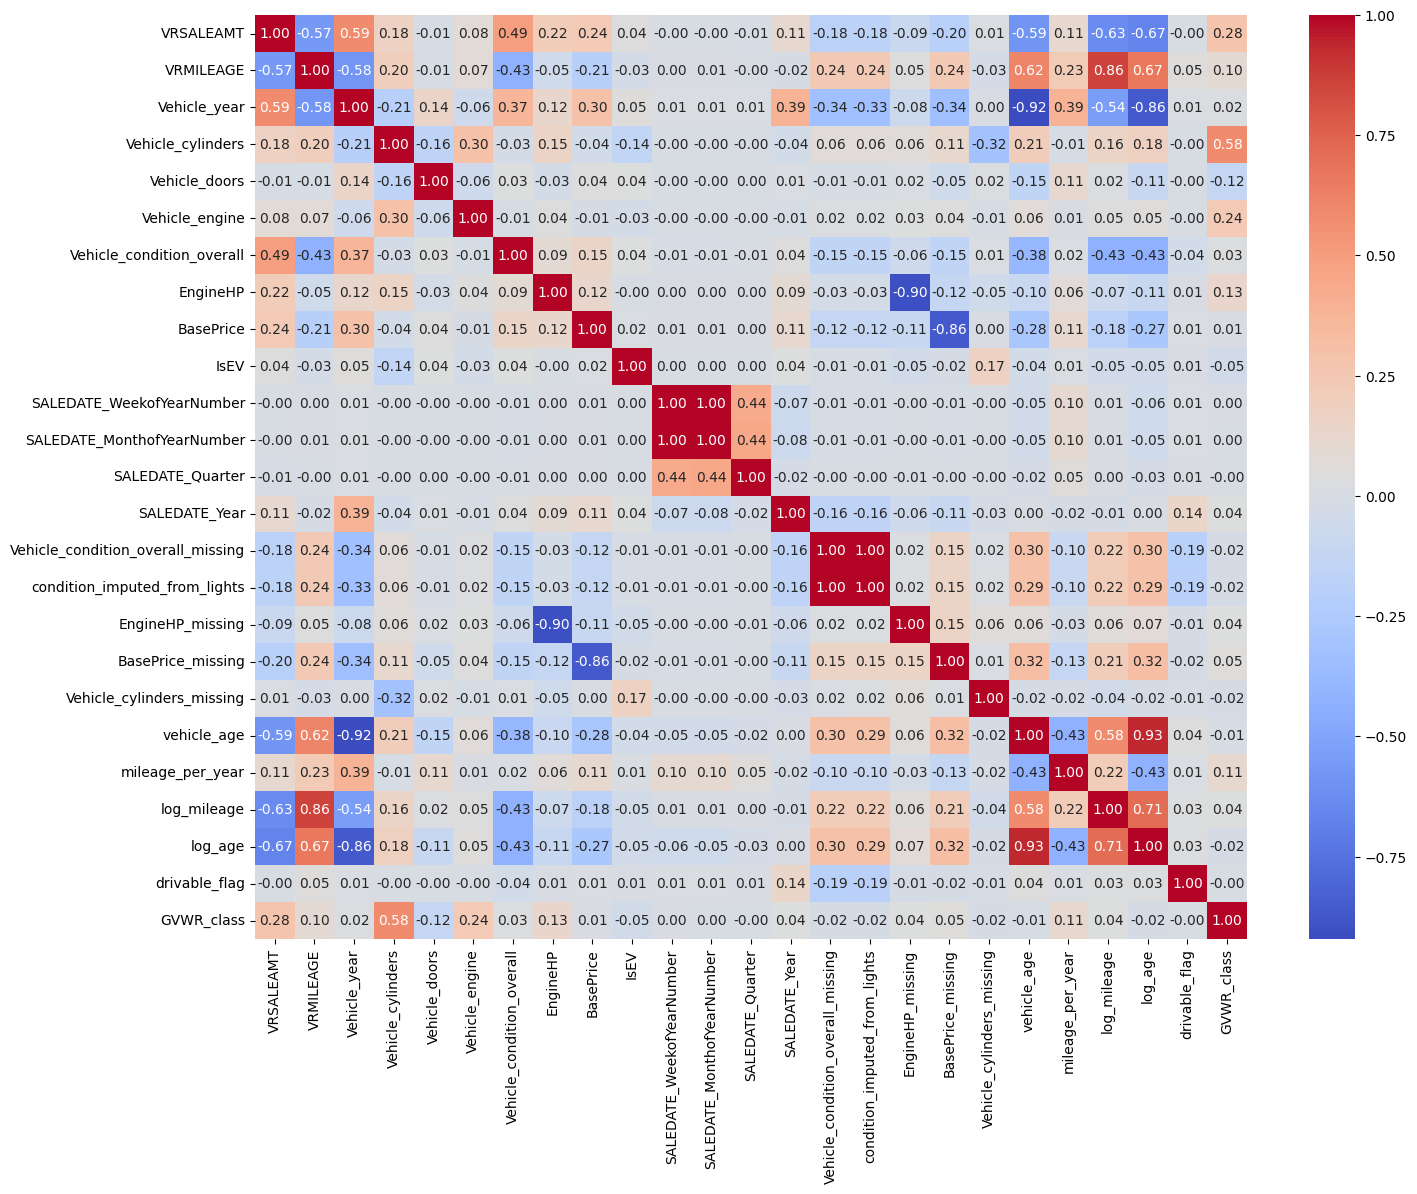

In [16]:
plt.figure(figsize=(16, 12))
sns.heatmap(cars_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [17]:
#Correlation plot
cor = cars_numeric.corr()
cor

,VRSALEAMT,VRMILEAGE,Vehicle_year,Vehicle_cylinders,Vehicle_doors,Vehicle_engine,Vehicle_condition_overall,EngineHP,BasePrice,IsEV,SALEDATE_WeekofYearNumber,SALEDATE_MonthofYearNumber,SALEDATE_Quarter,SALEDATE_Year,Vehicle_condition_overall_missing,condition_imputed_from_lights,EngineHP_missing,BasePrice_missing,Vehicle_cylinders_missing,vehicle_age,mileage_per_year,log_mileage,log_age,drivable_flag,GVWR_class
VRSALEAMT,1.000000,-0.567889,0.586671,0.180279,-0.011644,0.081429,0.491375,0.222332,0.238374,0.042096,-0.002504,-0.004651,-0.009415,0.113919,-0.179212,-0.178040,-0.090329,-0.195799,0.012700,-0.587995,0.106916,-0.630879,-0.667410,-0.000242,0.283284
VRMILEAGE,-0.567889,1.000000,-0.576343,0.199263,-0.007419,0.069584,-0.429099,-0.052666,-0.206607,-0.030574,0.004835,0.005007,-0.000325,-0.019450,0.244510,0.243860,0.046127,0.242433,-0.027205,0.616649,0.227391,0.858793,0.665089,0.049075,0.098535
Vehicle_year,0.586671,-0.576343,1.000000,-0.206312,0.144668,-0.062700,0.370432,0.124676,0.297381,0.049274,0.013581,0.010171,0.012235,0.386341,-0.335716,-0.333160,-0.075646,-0.341929,0.004750,-0.921311,0.390088,-0.542860,-0.860766,0.014231,0.021227
Vehicle_cylinders,0.180279,0.199263,-0.206312,1.000000,-0.157941,0.298635,-0.028930,0.154647,-0.036660,-0.137526,-0.002666,-0.002509,-0.003513,-0.042505,0.064803,0.064515,0.055349,0.111326,-0.317432,0.205761,-0.011198,0.155262,0.182982,-0.003560,0.584160
Vehicle_doors,-0.011644,-0.007419,0.144668,-0.157941,1.000000,-0.061486,0.031976,-0.034609,0.044585,0.036674,-0.001115,-0.000898,0.001437,0.010124,-0.007315,-0.007156,0.016635,-0.054271,0.018847,-0.152587,0.111864,0.021478,-0.109433,-0.002566,-0.120370
Vehicle_engine,0.081429,0.069584,-0.062700,0.298635,-0.061486,1.000000,-0.007319,0.039599,-0.013914,-0.032614,-0.000803,-0.000868,-0.001618,-0.012632,0.018143,0.018177,0.034653,0.042694,-0.007759,0.062626,0.007530,0.045750,0.053987,-0.002229,0.238874
Vehicle_condition_overall,0.491375,-0.429099,0.370432,-0.028930,0.031976,-0.007319,1.000000,0.091231,0.147539,0.036075,-0.010253,-0.010517,-0.005466,0.042474,-0.149142,-0.149606,-0.061194,-0.153495,0.009539,-0.383706,0.016216,-0.433267,-0.429203,-0.037457,0.031015
EngineHP,0.222332,-0.052666,0.124676,0.154647,-0.034609,0.039599,0.091231,1.000000,0.124637,-0.001989,0.004759,0.003836,0.004735,0.087220,-0.031410,-0.031348,-0.903357,-0.124557,-0.052604,-0.098400,0.062769,-0.066330,-0.105513,0.008404,0.129898
BasePrice,0.238374,-0.206607,0.297381,-0.036660,0.044585,-0.013914,0.147539,0.124637,1.000000,0.016720,0.006897,0.005645,0.004481,0.107214,-0.120974,-0.120021,-0.109687,-0.858170,0.002541,-0.277233,0.107600,-0.178304,-0.270820,0.014371,0.006988
IsEV,0.042096,-0.030574,0.049274,-0.137526,0.036674,-0.032614,0.036075,-0.001989,0.016720,1.000000,0.000707,0.000703,0.001134,0.035232,-0.008561,-0.008749,-0.046412,-0.016099,0.173261,-0.038558,0.010434,-0.050210,-0.047494,0.009304,-0.045905


In [18]:
cars.isnull().sum()

Location_Region                           0
VRLOCATION                                0
VRSALEAMT                                 0
VRMILEAGE                                 0
Vehicle_year                              0
Trim                                      0
Series                                    0
Vehicle_cylinders                         0
Vehicle_botcolor                     210456
Vehicle_doors                         41719
Vehicle_trantype                          0
Vehicle_engine                        10044
Vehicle_drive                             0
Vehicle_condition_drivable                0
Vehicle_condition_overall                 0
BodyClass                                 0
DriveType                                 0
EngineHP                                  0
FuelTypePrimary                           0
EngineConfiguration                       0
EngineModel                               0
GVWR                                  11929
PlantCountry                    

Data Preparation

In [19]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute   import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

In [20]:
categorical_cols = cars.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical:", categorical_cols)

Categorical: ['Location_Region', 'VRLOCATION', 'Trim', 'Series', 'Vehicle_botcolor', 'Vehicle_trantype', 'Vehicle_drive', 'Vehicle_condition_drivable', 'BodyClass', 'DriveType', 'FuelTypePrimary', 'EngineConfiguration', 'EngineModel', 'GVWR', 'PlantCountry', 'EVType', 'MarketSegment', 'Model', 'Make', 'VRSALEDATE', 'Misc_SalesChannel']


In [21]:
# remove engine from your list of categoricals...
categorical_feats = [
    'Location_Region', 'VRLOCATION', 'Trim', 'Series', 'Vehicle_botcolor', 'Vehicle_trantype', 'Vehicle_drive', 
    'Vehicle_condition_drivable', 'BodyClass', 'DriveType', 'FuelTypePrimary', 'EngineConfiguration', 'EngineModel', 
    'GVWR', 'PlantCountry', 'IsEV', 'EVType', 'MarketSegment', 'Model', 'Make','Misc_SalesChannel'
]
# …and add it into numeric_feats
numeric_feats = [
    'VRMILEAGE','Vehicle_year','Vehicle_cylinders','Vehicle_doors','Vehicle_engine',
    'Vehicle_condition_overall','EngineHP','BasePrice','SALEDATE_WeekofYearNumber','SALEDATE_MonthofYearNumber',
    'SALEDATE_Quarter','SALEDATE_Year','vehicle_age','mileage_per_year','log_mileage','log_age',
    'drivable_flag','GVWR_class','Vehicle_condition_overall_missing','condition_imputed_from_lights','EngineHP_missing','BasePrice_missing','Vehicle_cylinders_missing'
]


In [22]:
from scipy.stats import skew
skewness = skew(cars['Vehicle_condition_overall'].dropna())
print("Skewness:", skewness)

Skewness: 0.0738954171538353


In [23]:
X_external = cars_test[numeric_feats + categorical_feats]

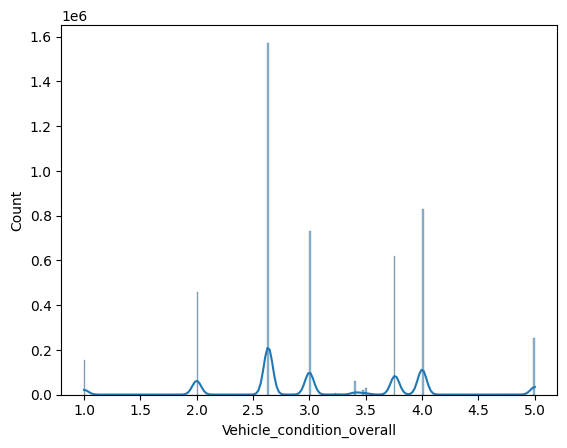

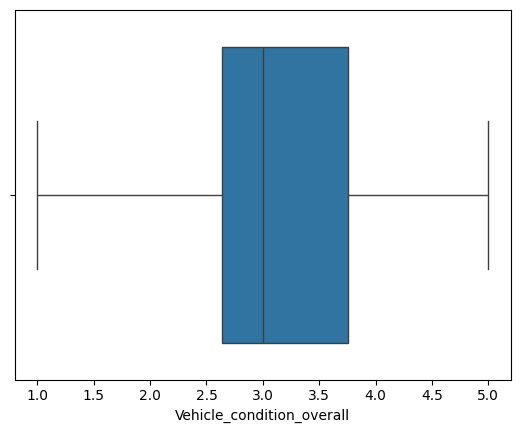

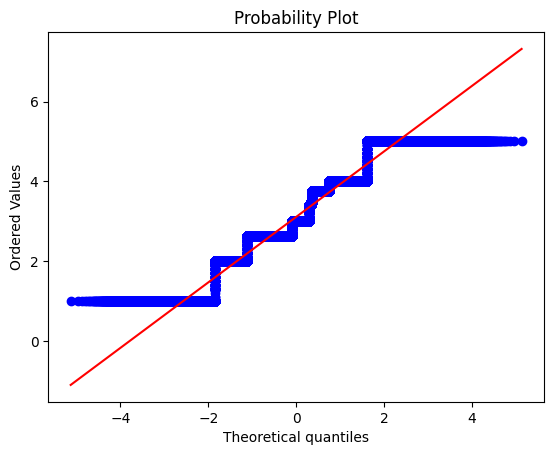

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

sns.histplot(cars['Vehicle_condition_overall'], kde=True)
plt.show()

sns.boxplot(x=cars['Vehicle_condition_overall'])
plt.show()

stats.probplot(cars['Vehicle_condition_overall'].dropna(), dist="norm", plot=plt)
plt.show()

In [25]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale',   StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown', add_indicator=True)),
    ('ohe',      OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_feats),
    ('cat', cat_pipe, categorical_feats),
], remainder='drop', sparse_threshold=1.0)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [27]:
# ensure sale_date exists and is datetime
assert "sale_date" in cars.columns, "sale_date missing—did you run clean_and_fix_temporal()?"
assert np.issubdtype(cars["sale_date"].dtype, np.datetime64), "sale_date must be datetime"

# Sort & split (as you already do)
cars = cars.dropna(subset=["sale_date"]).sort_values("sale_date")
q90 = cars["sale_date"].quantile(0.90)
q95 = cars["sale_date"].quantile(0.95)

train_mask = cars["sale_date"] < q90
valid_mask = (cars["sale_date"] >= q90) & (cars["sale_date"] < q95)
test_mask  = cars["sale_date"] >= q95

# Build X/y WITHOUT sale_date
X_train = cars.loc[train_mask, numeric_feats + categorical_feats]
y_train = cars.loc[train_mask, "VRSALEAMT"]
X_test  = cars.loc[test_mask,  numeric_feats + categorical_feats]
y_test  = cars.loc[test_mask,  "VRSALEAMT"]

# ✅ Print date ranges from the source df, not from X_* (sale_date isn't a feature)
print("Train range:", cars.loc[train_mask, "sale_date"].min(), "→", cars.loc[train_mask, "sale_date"].max())
print("Test range :", cars.loc[test_mask,  "sale_date"].min(),  "→", cars.loc[test_mask,  "sale_date"].max())
print("Train size :", len(X_train))
print("Test size  :", len(X_test))

Train range: 2019-01-02 00:00:00 → 2025-07-28 00:00:00
Test range : 2025-11-13 00:00:00 → 2026-03-13 00:00:00
Train size : 4268893
Test size  : 240652


In [28]:
# 4. Helper to build a full pipeline + extract coef names
def make_model_pipeline(model, poly=False):
    steps = []
    if poly:
        # expand numeric features to polynomial degree 2
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))
        steps.append(('preproc', preprocessor))
        steps.append(('reg', model))
    return Pipeline(steps)

def get_feature_names(pipeline):
    """
    After fitting, get the transformed feature names in order, so you can map back to coefficients.
    Requires sklearn ≥ 1.0 for ColumnTransformer.get_feature_names_out.
    """
    # name from the 'preproc' step
    feat_names = pipeline.named_steps['preproc'].get_feature_names_out()
    if 'poly' in pipeline.named_steps:
        # if polynomial, get names from poly step
        feat_names = pipeline.named_steps['poly'].get_feature_names_out(feat_names)
    return feat_names

In [29]:
from sklearn.compose import TransformedTargetRegressor

def with_log_target(pipeline_or_estimator):
    return TransformedTargetRegressor(
        regressor=pipeline_or_estimator,
        func=np.log1p,      # y' = log(1 + y)
        inverse_func=np.expm1  # y = exp(y') - 1
    )

XGBoost

In [30]:
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from bayes_opt import BayesianOptimization
from sklearn.metrics import r2_score

In [31]:
# 1) Choose which categoricals to target-encode (high cardinality)
high_card = ["Model","Trim","Series","EngineModel"]
high_card = [c for c in high_card if c in X_train.columns]

In [32]:
# 2) Low-card categoricals = original list minus the high-card ones
low_card_cats = [c for c in categorical_feats if c not in high_card]

In [33]:
# 3) Leakage-safe OOF target encoding helper
from sklearn.model_selection import KFold

def oof_target_encode(train_df, test_df, col, target, n_splits=5, smoothing=50):
    """
    Returns (te_train, te_test) for column `col` using leakage-safe OOF means with smoothing.
    """
    global_mean = train_df[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    te_train = pd.Series(np.nan, index=train_df.index, dtype=float)

    for tr_idx, val_idx in kf.split(train_df):
        tr = train_df.iloc[tr_idx]
        stats = tr.groupby(col)[target].agg(['count','mean'])
        stats["te"] = (stats["count"]*stats["mean"] + smoothing*global_mean) / (stats["count"] + smoothing)
        te_train.iloc[val_idx] = train_df.iloc[val_idx][col].map(stats["te"]).fillna(global_mean)

    # Fit on full train to transform test
    stats_full = train_df.groupby(col)[target].agg(['count','mean'])
    stats_full["te"] = (stats_full["count"]*stats_full["mean"] + smoothing*global_mean) / (stats_full["count"] + smoothing)
    te_test = test_df[col].map(stats_full["te"]).fillna(global_mean)

    return te_train.astype('float32'), te_test.astype('float32')

In [34]:
# 4) Apply OOF TE to train/test AND also prep a transformer for your external set
for col in high_card:
    tr_te, te_te = oof_target_encode(
        train_df=pd.concat([X_train, y_train], axis=1),
        test_df=X_test,
        col=col,
        target="VRSALEAMT"
    )
    X_train[f"te__{col}"] = tr_te.values
    X_test[f"te__{col}"]  = te_te.values

In [35]:
# 5) Do the same transform for your external data (cars_test / X_external)
#    Use ONLY training data stats to encode external
if 'X_external' in globals():
    # reuse the same function but with train_df from the training split
    train_w_target = pd.concat([X_train.drop(columns=[c for c in X_train.columns if c.startswith("te__")], errors='ignore'),
                                y_train], axis=1)
    for col in high_card:
        tr_te_dummy, te_ext = oof_target_encode(
            train_df=train_w_target.rename(columns={"VRSALEAMT": "VRSALEAMT"}),
            test_df=X_external,
            col=col,
            target="VRSALEAMT"
        )
        X_external[f"te__{col}"] = te_ext.values

In [36]:
# 6) Update your feature lists:
#    - Drop high-card originals from categorical_feats (OHE won’t touch them)
#    - Add the new TE columns to numeric_feats (they’re numeric now)
categorical_feats = [c for c in categorical_feats if c in X_train.columns and c not in high_card]
te_cols = [f"te__{c}" for c in high_card]
numeric_feats = list(dict.fromkeys(list(numeric_feats) + te_cols))  # de-dup while preserving order

In [37]:
# 7) Rebuild the preprocessor to OHE ONLY the remaining low-card categoricals
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])  # no scaler

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown', add_indicator=True)),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_feats),
    ('cat', cat_pipe, categorical_feats),
], remainder='drop', sparse_threshold=1.0)

In [38]:
num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[num_cols] = X_train[num_cols].astype('float32')
X_test[num_cols]  = X_test[num_cols].astype('float32')
X_external[num_cols]  = X_external[num_cols].astype('float32')

In [144]:
# import optuna
# import numpy as np
# import os
# import scipy.sparse as sp
# import xgboost as xgb
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.base import clone

# # ===== USER KNOBS =====
# N_TRIALS = 100
# TIME_BUDGET_SECONDS = None
# N_SPLITS = 3
# FOLD_SAMPLE_FRAC = 0.5     # tune on ~35% of each fold; set to 1.0 if you can afford it
# USE_GPU = False             # True if you have CUDA; uses 'gpu_hist'
# LOG_TARGET = True
# XGB_THREADS = max(1, os.cpu_count() // 2)
# # ======================

# def _fmt_params(d):
#     out = {}
#     for k, v in d.items():
#         out[k] = float(f"{v:.5g}") if isinstance(v, float) else v
#     return out

# def _chronologically_sorted(X, y):
#     assert "sale_date" in X.columns, "Need sale_date for time-aware splits."
#     order = np.argsort(X["sale_date"].values)
#     Xs = X.iloc[order].reset_index(drop=True)
#     ys = y.iloc[order].reset_index(drop=True)
#     return Xs, ys

# # 1) Build a parallel sale-date Series for the training window
# #    (use whatever your true train mask came from)
# sale_dates_train = cars.loc[train_mask, "sale_date"]

# # If your sale_date is not datetime (e.g., integers like 20250101), coerce it:
# if not np.issubdtype(sale_dates_train.dtype, np.datetime64):
#     # try to convert 'YYYYMMDD' ints/strings to datetime
#     sale_dates_train = pd.to_datetime(sale_dates_train.astype(str), format="%Y%m%d", errors="coerce")

# # 2) Helper that sorts X/y by an external sale-date Series
# def _chronologically_sorted(X, y, sale_dates):
#     order = np.argsort(sale_dates.values)   # NaT will go last; fine for CV
#     Xs = X.iloc[order].reset_index(drop=True)
#     ys = y.iloc[order].reset_index(drop=True)
#     return Xs, ys

# # 3) Sort once up-front (sale_date is NOT included in model features)
# X_train_sorted, y_train_sorted = _chronologically_sorted(X_train, y_train, sale_dates_train)

# # Optional: small helper to randomly sample each training fold
# def _subset_idx(idx, frac, seed):
#     if frac >= 1.0: 
#         return idx
#     rng = np.random.default_rng(seed)
#     take = int(len(idx) * frac)
#     return np.array(idx)[rng.choice(len(idx), size=take, replace=False)]

# def objective(trial):
#     # ---------- Search space tuned for ~4M rows ----------
#     params = dict(
#         objective="reg:squarederror",
#         eval_metric="rmse",
#         tree_method="gpu_hist" if USE_GPU else "hist",
#         grow_policy="lossguide",
#         # use leaves instead of depth; depth ignored when lossguide
#         max_depth=0,
#         max_leaves=trial.suggest_int("max_leaves", 512, 4096, log=True),
#         max_bin=trial.suggest_int("max_bin", 128, 512, log=True),
#         learning_rate=trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
#         min_child_weight=trial.suggest_int("min_child_weight", 20, 200),
#         gamma=trial.suggest_float("gamma", 0.0, 10.0),
#         # stronger regularization ranges for big data
#         reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 50.0, log=True),
#         reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 300.0, log=True),
#         subsample=trial.suggest_float("subsample", 0.7, 0.9),
#         colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
#         colsample_bynode=trial.suggest_float("colsample_bynode", 0.5, 0.9),
#         # threading/verbosity
#         nthread=XGB_THREADS,
#         verbosity=0,
#     )
#     num_boost_round = trial.suggest_int("n_estimators", 3000, 12000)  # early stopping will truncate

#     tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=7)
#     rmse_scores = []

#     for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sorted), start=1):
#         # Optionally sample each training fold to save time/RAM
#         tr_idx_sub = _subset_idx(tr_idx, FOLD_SAMPLE_FRAC, seed=42 + fold)

#         X_tr_raw = X_train_sorted.iloc[tr_idx_sub]
#         y_tr_raw = y_train_sorted.iloc[tr_idx_sub]
#         X_val_raw = X_train_sorted.iloc[val_idx]
#         y_val_raw = y_train_sorted.iloc[val_idx]

#         # Fit preprocessor per fold (NO leakage), transform to sparse
#         preproc = clone(preprocessor).fit(X_tr_raw, y_tr_raw)
#         X_tr = preproc.transform(X_tr_raw)
#         X_val = preproc.transform(X_val_raw)

#         # Ensure sparse CSR float32; DO NOT densify
#         if not sp.issparse(X_tr):
#             X_tr = sp.csr_matrix(X_tr)
#         if not sp.issparse(X_val):
#             X_val = sp.csr_matrix(X_val)
#         X_tr = X_tr.astype(np.float32)
#         X_val = X_val.astype(np.float32)

#         # Log target if desired
#         y_tr = np.log1p(y_tr_raw.values).astype(np.float32) if LOG_TARGET else y_tr_raw.values.astype(np.float32)
#         y_val = np.log1p(y_val_raw.values).astype(np.float32) if LOG_TARGET else y_val_raw.values.astype(np.float32)

#         dtr  = xgb.DMatrix(X_tr, label=y_tr)
#         dval = xgb.DMatrix(X_val, label=y_val)

#         booster = xgb.train(
#             params,
#             dtrain=dtr,
#             num_boost_round=num_boost_round,
#             evals=[(dval, "valid")],
#             callbacks=[xgb.callback.EarlyStopping(rounds=300, save_best=True)],
#             verbose_eval=False
#         )

#         # Predict (already on the best iteration)
#         y_pred = booster.inplace_predict(X_val)
#         # Evaluate on original scale
#         if LOG_TARGET:
#             y_pred_eval = np.expm1(y_pred)
#             y_val_eval = np.expm1(y_val)
#         else:
#             y_pred_eval = y_pred
#             y_val_eval = y_val

#         rmse = float(np.sqrt(np.mean((y_val_eval - y_pred_eval) ** 2)))
#         rmse_scores.append(rmse)

#         trial.report(-rmse, step=fold)
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()

#     return -float(np.mean(rmse_scores))  # maximize negative RMSE

# # ---- Sampler & pruner ----
# sampler = optuna.samplers.TPESampler(
#     seed=42, n_startup_trials=10, n_ei_candidates=12, multivariate=True, group=True
# )
# pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3)

# study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
# study.optimize(
#     objective,
#     n_trials=N_TRIALS if TIME_BUDGET_SECONDS is None else None,
#     timeout=TIME_BUDGET_SECONDS,
#     n_jobs=1,
#     show_progress_bar=True
# )

# print("\n--- OPTUNA COMPLETE ---")
# print(f"Best mean -RMSE: {-study.best_value:.6f}")
# print("Best params:")
# for k, v in _fmt_params(study.best_params).items():
#     print(f"  {k}: {v}")

In [39]:
xgb_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('xgb', XGBRegressor(
        # fixed hyperparameters from BayesOpt:
        tree_method = 'hist',
        device = 'cpu',
        max_leaves = 1205,
        max_bin = 370,
        learning_rate=0.05991643999637987,
        subsample=0.7851391246889514,
        colsample_bytree=0.6327858315456939,
        colsample_bynode = 0.5647362363865992,
        gamma=0.061018289094657896,
        min_child_weight=30,
        reg_alpha=0.021863364023749922,
        reg_lambda=0.33108221549428407,
        # keep the rest as before:
        grow_policy='lossguide',
        objective='reg:squarederror',
        eval_metric='rmse',
        n_estimators=8551,
    ))
])

xgb_pipeline_ttr = with_log_target(xgb_pipeline)

In [40]:
import joblib
import numpy as np
import pandas as pd

# ============================
# INPUTS YOU ALREADY HAVE
# ============================
numeric_feats = [
    'VRMILEAGE','Vehicle_year','Vehicle_cylinders','Vehicle_doors','Vehicle_engine',
    'Vehicle_condition_overall','EngineHP','BasePrice','SALEDATE_WeekofYearNumber',
    'SALEDATE_MonthofYearNumber','SALEDATE_Quarter','SALEDATE_Year','vehicle_age',
    'mileage_per_year','log_mileage','log_age','drivable_flag','GVWR_class',
    'te__Model','te__Trim','te__Series','te__EngineModel'
]

categorical_feats = [
    'Location_Region','Vehicle_botcolor','Vehicle_trantype','Vehicle_drive','VRLOCATION',
    'Vehicle_condition_drivable','BodyClass','DriveType','FuelTypePrimary',
    'EngineConfiguration','GVWR','PlantCountry','IsEV','EVType','MarketSegment','Make','VRLIGHTS','Misc_SalesChannel'
]

high_card = ['Model', 'Trim', 'Series', 'EngineModel']

TARGET = "VRSALEAMT"
BUNDLE_PATH = "xgb_vehicle_price_bundle.joblib"
SCHEMA_VERSION = 1
TE_SMOOTHING = 50.0

# ============================
# 1) SAFETY: de-dup lists and basic checks
# ============================
numeric_feats      = list(pd.Index(numeric_feats).unique())
categorical_feats  = list(pd.Index(categorical_feats).unique())
high_card          = list(pd.Index(high_card).unique())

# TE columns implied by high_card:
te_cols = [f"te__{c}" for c in high_card]

# Ensure numeric_feats contains all te_cols (and only those you intend)
missing_te_in_numeric = [c for c in te_cols if c not in numeric_feats]
if missing_te_in_numeric:
    raise ValueError(f"numeric_feats is missing TE columns: {missing_te_in_numeric}")

# Raw numeric feats = numeric feats excluding te__*
numeric_feats_raw = [c for c in numeric_feats if not c.startswith("te__")]
numeric_feats_raw = list(pd.Index(numeric_feats_raw).unique())

# ============================
# 2) TE MAPS: fit + apply (hardened)
# ============================
def fit_te_maps(X_train_raw: pd.DataFrame,
                y_train: pd.Series,
                high_card: list,
                smoothing: float = 50.0) -> dict:
    """
    Fit target-encoding maps on TRAIN ONLY with smoothing.
    Stores per-column mapping + global mean.
    """
    te_maps = {}
    y_train = pd.to_numeric(y_train, errors="coerce")
    global_mean = float(np.nanmean(y_train))

    for col in high_card:
        if col not in X_train_raw.columns:
            # If missing, store empty mapping; will default to global mean
            te_maps[col] = {"global_mean": global_mean, "mapping": {}}
            continue

        tmp = pd.DataFrame({"col": X_train_raw[col].astype("object"), "y": y_train}).copy()
        tmp["col"] = tmp["col"].fillna("__MISSING__")
        stats = tmp.groupby("col")["y"].agg(["count", "mean"])

        te = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
        te_maps[col] = {"global_mean": global_mean, "mapping": te.to_dict()}

    return te_maps


def apply_te_maps(df: pd.DataFrame,
                  te_maps: dict,
                  high_card: list) -> pd.DataFrame:
    """
    Apply TE maps. If col missing or unseen category, falls back to global_mean.
    Produces float32 te__* columns.
    """
    df = df.copy()
    for col in high_card:
        g = float(te_maps[col]["global_mean"])
        m = te_maps[col]["mapping"]

        out_col = f"te__{col}"

        if col not in df.columns:
            df[out_col] = g
        else:
            s = df[col].astype("object").fillna("__MISSING__")
            df[out_col] = s.map(m).fillna(g)

        df[out_col] = pd.to_numeric(df[out_col], errors="coerce").fillna(g).astype("float32")

    return df


def make_xgb_features(df_clean: pd.DataFrame,
                      te_maps: dict,
                      high_card: list,
                      numeric_feats: list,
                      categorical_feats: list) -> pd.DataFrame:
    """
    Construct the exact input frame expected by your ColumnTransformer:
      - Adds te__* columns
      - Returns only numeric_feats + categorical_feats (NO raw high_card categoricals)
      - Coerces numeric to float32
      - Ensures categoricals exist and are object dtype (safe for OHE)
    """
    tmp = apply_te_maps(df_clean, te_maps, high_card)

    # Ensure required columns exist
    needed = list(pd.Index(numeric_feats + categorical_feats).unique())
    missing = [c for c in needed if c not in tmp.columns]
    if missing:
        raise KeyError(f"make_xgb_features: missing required columns: {missing}")

    X = tmp[needed].copy()

    # Numeric coercion
    for c in numeric_feats:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")

    # Categorical coercion (OHE pipeline will impute Unknown anyway)
    for c in categorical_feats:
        X[c] = X[c].astype("object")

    return X

# ============================
# 3) BUILD TRAIN RAW FRAME (FIXES YOUR KeyError)
# ============================
# IMPORTANT: cars DOES NOT contain te__* yet. Use numeric_feats_raw + categorical_feats + high_card
raw_cols_needed = list(pd.Index(numeric_feats_raw + categorical_feats + high_card).unique())

missing_raw = [c for c in raw_cols_needed if c not in cars.columns]
if missing_raw:
    raise KeyError(f"These required raw columns are missing from cars: {missing_raw}")

# y_train_raw should align with the same train_mask index
y_train_raw = cars.loc[train_mask, TARGET].copy()
X_train_raw = cars.loc[train_mask, raw_cols_needed].copy()

# ============================
# 4) FIT TE MAPS ON TRAIN WINDOW ONLY
# ============================
te_maps = fit_te_maps(X_train_raw, y_train_raw, high_card=high_card, smoothing=TE_SMOOTHING)

# ============================
# 5) BUILD MODEL TRAIN MATRIX (HAS te__* NOW)
# ============================
X_train_for_model = make_xgb_features(
    df_clean=X_train_raw,
    te_maps=te_maps,
    high_card=high_card,
    numeric_feats=numeric_feats,            # includes te__*
    categorical_feats=categorical_feats     # low-card only
)

# ============================
# 6) FIT MODEL + SAVE BUNDLE
# ============================
xgb_pipeline_ttr.fit(X_train_for_model, y_train_raw)

bundle = {
    "model": xgb_pipeline_ttr,     # includes preprocessor + XGB + log-target wrapper
    "te_maps": te_maps,
    "high_card": high_card,
    "numeric_feats": numeric_feats,
    "categorical_feats": categorical_feats,
    "schema_version": SCHEMA_VERSION,
}

joblib.dump(bundle, BUNDLE_PATH, compress=0)
print(f"Saved: {BUNDLE_PATH}")

# ============================
# 7) OPTIONAL: QUICK INFERENCE HELPERS (recommended)
# ============================
def load_bundle(path=BUNDLE_PATH):
    b = joblib.load(path)
    required = ["model","te_maps","high_card","numeric_feats","categorical_feats","schema_version"]
    miss = [k for k in required if k not in b]
    if miss:
        raise ValueError(f"Bundle missing keys: {miss}")
    return b

def predict_from_bundle(df_clean: pd.DataFrame, bundle: dict) -> np.ndarray:
    X = make_xgb_features(
        df_clean=df_clean,
        te_maps=bundle["te_maps"],
        high_card=bundle["high_card"],
        numeric_feats=bundle["numeric_feats"],
        categorical_feats=bundle["categorical_feats"]
    )
    return bundle["model"].predict(X)

# Example usage:
# b = load_bundle()
# preds_test = predict_from_bundle(cars.loc[test_mask, raw_cols_needed], b)


Saved: xgb_vehicle_price_bundle.joblib


In [40]:
# 3. Fit & predict just like before
xgb_pipeline_ttr.fit(X_train, y_train)
xgb_predictions = xgb_pipeline_ttr.predict(X_test)
xgb_predictions_external = xgb_pipeline_ttr.predict(X_external)

In [41]:
xgb_r2 = r2_score(y_test, xgb_predictions)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions)

# Display results
print("📊 XGBoost Regression Evaluation Metrics")
print(f"R² Score  : {xgb_r2:.4f}")
print(f"MAE       : {xgb_mae:.2f}")
print(f"MSE       : {xgb_mse:.2f}")
print(f"RMSE      : {xgb_rmse:.2f}")
print(f"MAPE      : {xgb_mape:.2%}")

📊 XGBoost Regression Evaluation Metrics
R² Score  : 0.9463
MAE       : 1504.31
MSE       : 7186332.50
RMSE      : 2680.73
MAPE      : 29.15%


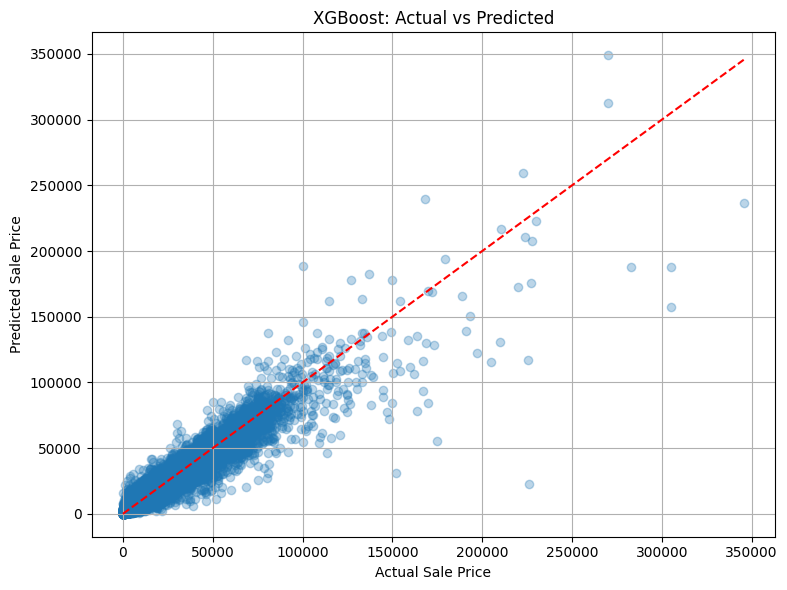

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, xgb_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('XGBoost: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
import shap
import matplotlib.pyplot as plt

CatBoost

In [147]:
# # === CatBoost + Optuna: 2-stage multi-fidelity tuner (ASHA; optional pruning callback) ===
# import os, sys, time, numpy as np, pandas as pd
# import optuna
# from optuna.trial import TrialState
# from optuna.pruners import SuccessiveHalvingPruner, HyperbandPruner
# from optuna.samplers import TPESampler
# from catboost import CatBoostRegressor, Pool, CatBoostError
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_squared_error

# # Try to import the integration callback; fall back if unavailable
# try:
#     from optuna.integration import CatBoostPruningCallback  # requires optuna-integration[catboost]
#     HAS_CB_PRUNE = True
# except Exception:
#     CatBoostPruningCallback = None
#     HAS_CB_PRUNE = False
#     print("[INFO] optuna-integration[catboost] not found; continuing without CatBoostPruningCallback "
#           "(pruning will occur between folds, not during iterations).", flush=True)

# # ================= USER KNOBS =================
# TARGET = "VRSALEAMT"
# USE_GPU = False
# LOG_TARGET = True
# SEED = 42
# THREADS = max(1, os.cpu_count() // 2)

# # Data budgets (multi-fidelity)
# STAGE1_MAX_TRAIN_ROWS = 250_000     # tiny/cheap
# STAGE2_MAX_TRAIN_ROWS = 800_000     # bigger, still tractable
# FOLD_SAMPLE_FRAC_S1 = 0.08          # stronger downsample early
# FOLD_SAMPLE_FRAC_S2 = 0.20

# # Iteration budgets (multi-fidelity)
# STAGE1_ITERS_MIN, STAGE1_ITERS_MAX = 300, 900
# STAGE2_ITERS_MIN, STAGE2_ITERS_MAX = 800, 2000

# EARLY_STOP_ROUNDS = 100
# N_SPLITS = 3
# GAP_ROWS = 0

# # Trials
# STAGE1_TRIALS = 25
# STAGE2_TRIALS = 10

# # Search space (coarse; we’ll narrow in Stage 2)
# DEPTH_RANGE = (6, 10)
# L2_RANGE = (3.0, 40.0)
# LR_RANGE = (0.02, 0.12)
# MDL_RANGE = (512, 4096)
# SUBSAMPLE_RANGE = (0.6, 0.95)
# RSM_RANGE = (0.7, 0.95)
# RAND_STR_RANGE = (0.0, 0.8)

# # ============================================================
# # Prepare data (assumes df 'cars' with 'sale_date' + TARGET)
# assert "sale_date" in cars.columns, "Need 'sale_date' for time-aware CV."
# cars_sorted = cars.dropna(subset=["sale_date"]).sort_values("sale_date").reset_index(drop=True)

# feature_cols = [c for c in cars_sorted.columns if c not in [TARGET, "sale_date"]]
# X_all = cars_sorted[feature_cols].copy()
# y_all = cars_sorted[TARGET].astype("float32").copy()
# mask = y_all.notna()
# X_all = X_all.loc[mask].reset_index(drop=True)
# y_all = y_all.loc[mask].reset_index(drop=True)

# cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
# num_cols = X_all.select_dtypes(include=[np.number, "boolean"]).columns.tolist()
# if cat_cols:
#     X_all.loc[:, cat_cols] = X_all.loc[:, cat_cols].fillna("__MISSING__").astype(str)
# if num_cols:
#     X_all.loc[:, num_cols] = (
#         X_all.loc[:, num_cols]
#         .replace([np.inf, -np.inf], np.nan)
#         .apply(pd.to_numeric, errors="coerce", downcast="float")
#     )
# cat_idx = [X_all.columns.get_loc(c) for c in cat_cols]

# def _subset_df(X, y, frac, seed):
#     if frac >= 1.0: return X, y
#     idx = X.index.to_series().sample(frac=frac, random_state=seed).index
#     return X.loc[idx], y.loc[idx]

# def _cap_recent_rows(X, y, cap):
#     if cap is None or len(X) <= cap: return X, y
#     return X.iloc[-cap:], y.iloc[-cap:]

# def _fmt(d):
#     out = {}
#     for k, v in d.items():
#         out[k] = float(f"{v:.5g}") if isinstance(v, float) else v
#     return out

# def make_objective(max_train_rows, fold_frac, iters_min, iters_max, refine_from=None):
#     """
#     Build an objective with a given data + iteration budget.
#     refine_from: dict of center params to narrow around (from Stage 1 best).
#     """
#     def near(center, width, lo=None, hi=None):
#         lo2, hi2 = center - width, center + width
#         if lo is not None: lo2 = max(lo2, lo)
#         if hi is not None: hi2 = min(hi2, hi)
#         return lo2, hi2

#     def objective(trial):
#         # ----- Search space -----
#         if refine_from is None:
#             depth = trial.suggest_int("depth", *DEPTH_RANGE)
#             l2 = trial.suggest_float("l2_leaf_reg", *L2_RANGE, log=True)
#             lr = trial.suggest_float("learning_rate", *LR_RANGE, log=True)
#             mdl = trial.suggest_int("min_data_in_leaf", *MDL_RANGE)
#             rsm = trial.suggest_float("rsm", *RSM_RANGE)
#             subsample = trial.suggest_float("subsample", *SUBSAMPLE_RANGE)
#             rand_str = trial.suggest_float("random_strength", *RAND_STR_RANGE)
#         else:
#             depth0 = refine_from.get("depth", 8)
#             l20 = refine_from.get("l2_leaf_reg", 10.0)
#             lr0 = refine_from.get("learning_rate", 0.06)
#             mdl0 = refine_from.get("min_data_in_leaf", 1500)
#             rsm0 = refine_from.get("rsm", 0.8)
#             sub0 = refine_from.get("subsample", 0.8)
#             rs0  = refine_from.get("random_strength", 0.2)

#             depth = trial.suggest_int("depth", max(6, depth0-1), min(10, depth0+1))
#             l2_lo, l2_hi = near(l20, l20*0.7, L2_RANGE[0], L2_RANGE[1])
#             l2 = trial.suggest_float("l2_leaf_reg", max(L2_RANGE[0], l2_lo), min(L2_RANGE[1], l2_hi), log=True)
#             lr_lo, lr_hi = near(lr0, max(0.005, lr0*0.5), LR_RANGE[0], LR_RANGE[1])
#             lr = trial.suggest_float("learning_rate", lr_lo, lr_hi, log=True)
#             mdl_lo, mdl_hi = near(mdl0, max(200, mdl0*0.5), MDL_RANGE[0], MDL_RANGE[1])
#             mdl = trial.suggest_int("min_data_in_leaf", int(mdl_lo), int(mdl_hi))
#             rsm_lo, rsm_hi = near(rsm0, 0.1, RSM_RANGE[0], RSM_RANGE[1])
#             rsm = trial.suggest_float("rsm", rsm_lo, rsm_hi)
#             sub_lo, sub_hi = near(sub0, 0.1, SUBSAMPLE_RANGE[0], SUBSAMPLE_RANGE[1])
#             subsample = trial.suggest_float("subsample", sub_lo, sub_hi)
#             rs_lo, rs_hi = near(rs0, 0.2, RAND_STR_RANGE[0], RAND_STR_RANGE[1])
#             rand_str = trial.suggest_float("random_strength", rs_lo, rs_hi)

#         iterations = trial.suggest_int("iterations", iters_min, iters_max)

#         params = dict(
#             loss_function="RMSE",
#             eval_metric="RMSE",
#             depth=depth,
#             learning_rate=lr,
#             rsm=rsm,
#             l2_leaf_reg=l2,
#             random_strength=rand_str,
#             iterations=iterations,
#             od_type="Iter",
#             od_wait=EARLY_STOP_ROUNDS,
#             use_best_model=True,
#             min_data_in_leaf=mdl,
#             one_hot_max_size=12,
#             border_count=64,
#             random_state=SEED,
#             thread_count=THREADS,
#             verbose=False,     # we may attach pruning callback
#             task_type="GPU" if USE_GPU else "CPU",
#             bootstrap_type="Bernoulli",
#             subsample=subsample,
#             allow_writing_files=False,
#             boosting_type="Ordered",
#         )

#         tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=GAP_ROWS)
#         rmses = []

#         for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_all), start=1):
#             X_tr_raw, y_tr_raw = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
#             X_val_raw, y_val_raw = X_all.iloc[val_idx], y_all.iloc[val_idx]

#             X_tr, y_tr = _subset_df(X_tr_raw, y_tr_raw, fold_frac, SEED + fold)
#             X_tr, y_tr = _cap_recent_rows(X_tr, y_tr, max_train_rows)
#             X_val, y_val = X_val_raw, y_val_raw

#             y_tr_fit = np.log1p(y_tr.values) if LOG_TARGET else y_tr.values
#             y_val_fit = np.log1p(y_val.values) if LOG_TARGET else y_val.values

#             train_pool = Pool(X_tr, label=y_tr_fit, cat_features=cat_idx)
#             valid_pool = Pool(X_val, label=y_val_fit, cat_features=cat_idx)

#             model = CatBoostRegressor(**params)

#             # Optional per-iteration pruning if integration is installed
#             kwargs = dict(
#                 verbose=False,
#                 early_stopping_rounds=EARLY_STOP_ROUNDS,
#             )
#             if HAS_CB_PRUNE:
#                 kwargs["callbacks"] = [CatBoostPruningCallback(trial, "RMSE")]

#             try:
#                 model.fit(train_pool, eval_set=valid_pool, **kwargs)
#             except (CatBoostError, MemoryError) as e:
#                 trial.set_user_attr("fit_error", str(e))
#                 # prune on OOM/alloc to keep study running
#                 raise optuna.exceptions.TrialPruned()

#             # Evaluate on original scale
#             y_pred_fit = model.predict(valid_pool)
#             y_pred = np.expm1(y_pred_fit) if LOG_TARGET else y_pred_fit
#             rmse = float(np.sqrt(mean_squared_error(y_val.values, y_pred)))
#             rmses.append(rmse)

#             # Report running mean so ASHA/Hyperband can prune between folds
#             trial.report(-np.mean(rmses), step=fold)
#             if trial.should_prune():
#                 raise optuna.exceptions.TrialPruned()

#         return -float(np.mean(rmses))

#     return objective

# def run_stage(n_trials, objective, pruner, study_name="catboost_tune"):
#     sampler = TPESampler(seed=SEED, n_startup_trials=8, multivariate=True, group=True)
#     study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=study_name)
#     study.optimize(objective, n_trials=n_trials, n_jobs=1, gc_after_trial=True, show_progress_bar=True)
#     return study

# # ---------------- Stage 1: coarse, cheap (ASHA) ----------------
# asha = SuccessiveHalvingPruner(min_resource=1, reduction_factor=3, min_early_stopping_rate=0)
# obj_s1 = make_objective(
#     max_train_rows=STAGE1_MAX_TRAIN_ROWS,
#     fold_frac=FOLD_SAMPLE_FRAC_S1,
#     iters_min=STAGE1_ITERS_MIN,
#     iters_max=STAGE1_ITERS_MAX,
# )
# print("=== Stage 1 (coarse, cheap) ===", flush=True)
# study1 = run_stage(STAGE1_TRIALS, obj_s1, asha, "catboost_s1")

# best_params_s1 = {}
# if any(t.state == TrialState.COMPLETE for t in study1.trials):
#     best_params_s1 = study1.best_trial.params
#     print("Stage 1 best RMSE ~", round(-study1.best_value, 4), flush=True)
#     print("Stage 1 best params:", _fmt(best_params_s1), flush=True)
# else:
#     print("Stage 1 finished with all trials pruned; consider easing budgets.", flush=True)

# # ---------------- Stage 2: refine near Stage 1 winner (Hyperband) ----------------
# if best_params_s1:
#     hb = HyperbandPruner(min_resource=1, max_resource=STAGE2_ITERS_MAX, reduction_factor=3)
#     obj_s2 = make_objective(
#         max_train_rows=STAGE2_MAX_TRAIN_ROWS,
#         fold_frac=FOLD_SAMPLE_FRAC_S2,
#         iters_min=STAGE2_ITERS_MIN,
#         iters_max=STAGE2_ITERS_MAX,
#         refine_from=best_params_s1
#     )
#     print("\n=== Stage 2 (refine near Stage 1 winner) ===", flush=True)
#     study2 = run_stage(STAGE2_TRIALS, obj_s2, hb, "catboost_s2")

#     if any(t.state == TrialState.COMPLETE for t in study2.trials):
#         print("\n--- FINAL ---", flush=True)
#         print("Best CV RMSE:", round(-study2.best_value, 6), flush=True)
#         print("Best params:", _fmt(study2.best_params), flush=True)
#     else:
#         print("Stage 2 had no completed trials; fall back to Stage 1 winner.", flush=True)
# else:
#     print("\nNo Stage 1 winner; try relaxing budgets (raise STAGE1_MAX_TRAIN_ROWS, FOLD_SAMPLE_FRAC_S1, "
#           "or widen iteration ranges).", flush=True)

In [44]:
from catboost import CatBoostRegressor
catboost_model = CatBoostRegressor(
    iterations= 1907,
    learning_rate= 0.093206,
    depth= int(8.0),
    rsm= 0.94136,
    l2_leaf_reg= 3.6763,
    random_strength = 0.68366,
    min_data_in_leaf = 3584,
    subsample = 0.93727,
    bootstrap_type = 'Bernoulli',
    loss_function='RMSE',                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
    verbose=0,
    random_state=42,
)

In [45]:
from sklearn.pipeline import Pipeline

catboost_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('catboost', catboost_model)
])

catboost_pipeline_ttr = with_log_target(catboost_pipeline)

In [46]:
# Fit the pipeline
catboost_pipeline_ttr.fit(X_train, y_train)

# Predict on test data
catboost_preds = catboost_pipeline_ttr.predict(X_test)
catboost_preds_external = catboost_pipeline_ttr.predict(X_external)

In [47]:
catboost_r2 = r2_score(y_test, catboost_preds)
catboost_mae = mean_absolute_error(y_test, catboost_preds)
catboost_mse = mean_squared_error(y_test, catboost_preds)
catboost_rmse = np.sqrt(catboost_mse)
catboost_mape = mean_absolute_percentage_error(y_test, catboost_preds)

# Display results
print("📊 catboost Regression Evaluation Metrics")
print(f"R² Score  : {catboost_r2:.4f}")
print(f"MAE       : {catboost_mae:.2f}")
print(f"MSE       : {catboost_mse:.2f}")
print(f"RMSE      : {catboost_rmse:.2f}")
print(f"MAPE      : {catboost_mape:.2%}")

📊 catboost Regression Evaluation Metrics
R² Score  : 0.9375
MAE       : 1570.20
MSE       : 8362141.76
RMSE      : 2891.74
MAPE      : 29.48%


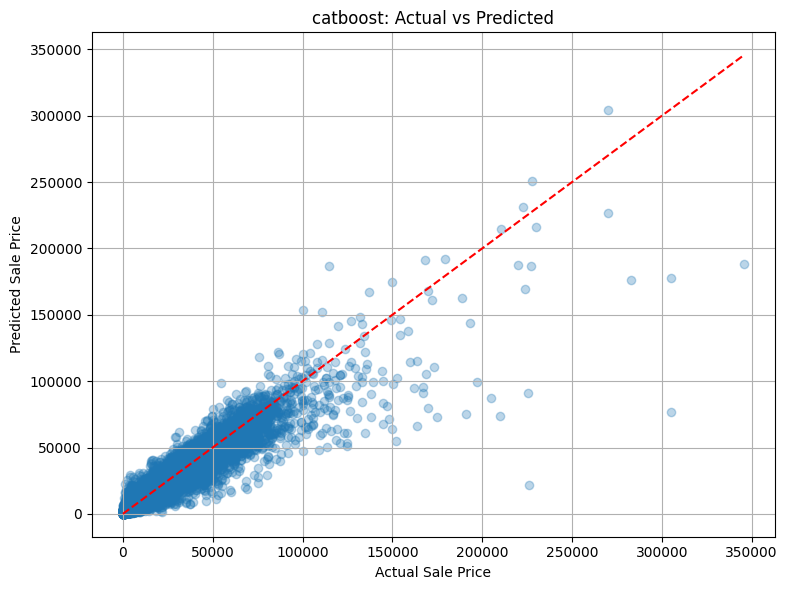

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, catboost_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('catboost: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

CatBoost Native Handling

In [49]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [50]:
categorical_feats = list(pd.Index(categorical_feats).unique())
numeric_feats     = list(pd.Index(numeric_feats).unique())
all_feats         = categorical_feats + numeric_feats  # order matters for indices

In [51]:
X_train_all    = X_train[all_feats].copy()
X_test_all     = X_test[all_feats].copy()
X_external_all = X_external[all_feats].copy()

In [52]:
# 2) Fill/convert categorical columns on ALL splits
def prep_cats(df, cat_cols):
    # Fill NaN, then cast to string/object (CatBoost wants strings/ints, not floats/NaN)
    df[cat_cols] = df[cat_cols].fillna('Unknown').astype(str)
    return df

X_train_all    = prep_cats(X_train_all,    categorical_feats)
X_test_all     = prep_cats(X_test_all,     categorical_feats)
X_external_all = prep_cats(X_external_all, categorical_feats)

In [53]:
# 3) Cat feature indices must match the columns you pass into Pool
cat_feature_indices = [all_feats.index(c) for c in categorical_feats]

# 4) Train on log-target and predict
y_train_log = np.log1p(y_train)

train_pool = Pool(X_train_all, y_train_log, cat_features=cat_feature_indices)
test_pool  = Pool(X_test_all,  cat_features=cat_feature_indices)
ext_pool   = Pool(X_external_all, cat_features=cat_feature_indices)

In [54]:
cat_model = CatBoostRegressor(
    iterations= 1907,
    learning_rate= 0.093206,
    depth= int(8.0),
    rsm= 0.94136,
    l2_leaf_reg= 3.6763,
    random_strength = 0.68366,
    min_data_in_leaf = 3584,
    subsample = 0.93727,
    bootstrap_type = 'Bernoulli',
    loss_function='RMSE',                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
    verbose=0,
    random_state=42,
)

cat_model.fit(train_pool)

In [55]:
cat_log_preds          = cat_model.predict(test_pool)
cat_preds              = np.expm1(cat_log_preds)

cat_log_preds_external = cat_model.predict(ext_pool)
cat_preds_external     = np.expm1(cat_log_preds_external)

In [56]:
cat_r2 = r2_score(y_test, cat_preds)
cat_mae = mean_absolute_error(y_test, cat_preds)
cat_mse = mean_squared_error(y_test, cat_preds)
cat_rmse = np.sqrt(cat_mse)
cat_mape = mean_absolute_percentage_error(y_test, cat_preds)

# Display results
print("📊 catboost Regression Evaluation Metrics")
print(f"R² Score  : {cat_r2:.4f}")
print(f"MAE       : {cat_mae:.2f}")
print(f"MSE       : {cat_mse:.2f}")
print(f"RMSE      : {cat_rmse:.2f}")
print(f"MAPE      : {cat_mape:.2%}")

📊 catboost Regression Evaluation Metrics
R² Score  : 0.9385
MAE       : 1573.40
MSE       : 8229701.69
RMSE      : 2868.75
MAPE      : 30.27%


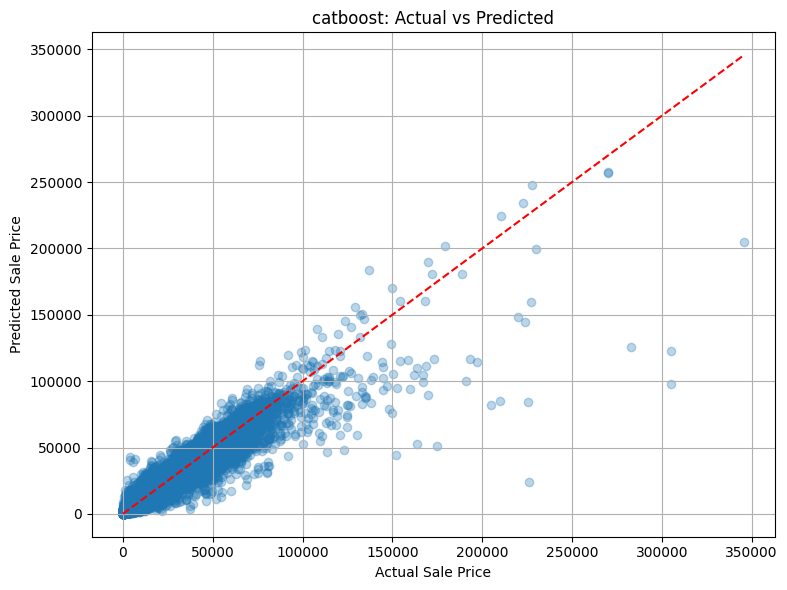

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, cat_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('catboost: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

Model Combination

In [58]:
import numpy as np
import pandas as pd

# Base models
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import cross_val_score

from sklearn.isotonic import IsotonicRegression
from scipy.optimize import nnls

import optuna
from optuna.samplers import TPESampler

In [59]:
# 0) SETTINGS
# --------------------------------
SEED = 42
RUN_LGBM_TUNING = True   # <<< set False if you just want default LGBM params
LGBM_N_TRIALS = 30       # Optuna trials for LightGBM
LGBM_SUB_FRAC = 0.20     # fraction of train data to use for LGBM tuning if huge

In [60]:
# 1) LOG-TARGET WRAPPER
# --------------------------------
from sklearn.base import BaseEstimator, RegressorMixin, clone

class LogTargetRegressor(BaseEstimator, RegressorMixin):
    """
    Wraps a regressor so it fits on log1p(y) and predicts on original scale via expm1.
    """
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        self.est_ = clone(self.base_estimator)
        y_log = np.log1p(np.asarray(y, dtype=float))
        self.est_.fit(X, y_log)
        return self

    def predict(self, X):
        y_log_pred = self.est_.predict(X)
        return np.expm1(y_log_pred)

def with_log_target(est):
    return LogTargetRegressor(est)

In [61]:
# 2) YOUR TUNED BASE MODELS
# --------------------------------
catboost_model = CatBoostRegressor(
    iterations= 1907,
    learning_rate= 0.093206,
    depth= int(8.0),
    rsm= 0.94136,
    l2_leaf_reg= 3.6763,
    random_strength = 0.68366,
    min_data_in_leaf = 3584,
    subsample = 0.93727,
    bootstrap_type = 'Bernoulli',
    loss_function='RMSE',                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
    verbose=0,
    random_state=42,
)

xgb_model = XGBRegressor(
    tree_method = 'hist',
    device = 'cpu',
    max_leaves = 1205,
    max_bin = 370,
    learning_rate=0.05991643999637987,
    subsample=0.7851391246889514,
    colsample_bytree=0.6327858315456939,
    colsample_bynode = 0.5647362363865992,
    gamma=0.061018289094657896,
    min_child_weight=30,
    reg_alpha=0.021863364023749922,
    reg_lambda=0.33108221549428407,
    # keep the rest as before:
    grow_policy='lossguide',
    objective='reg:squarederror',
    eval_metric='rmse',
    n_estimators=8551,
)

In [62]:
# 2) DEFINE STACKED MODEL (CatBoost + XGB + Ridge meta)
# ==================================================

meta = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(alpha=1.0, random_state=42)
)

stack = StackingRegressor(
    estimators=[('cat', catboost_model), ('xgb', xgb_model)],
    final_estimator=meta,
    passthrough=True,   # we might tune this later
    cv=5,
    n_jobs=1            # keep this 1 to avoid weirdness on Windows
)

stacking_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('stack',   stack),
])

stack_log = with_log_target(stacking_pipeline)

In [63]:
# 3) STACKING REGRESSOR (LOG TARGET)
# --------------------------------
meta = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(alpha=82.53877684201471, random_state=SEED)
)

stack = StackingRegressor(
    estimators=[('cat', catboost_model), ('xgb', xgb_model)],
    final_estimator=meta,
    passthrough=False,            # keep raw preprocessed features at meta layer
    cv=5,
    n_jobs=1                     # keep single-threaded inside stack to avoid OS weirdness
)

# preprocessor must be defined earlier by you:
#   - e.g. ColumnTransformer([...]) handling cat/num
#   - we assume it exists: preprocessor

stacking_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('stack',   stack),
])

# Sometimes StackingRegressor exposes n_jobs, make sure it's safe (no multiprocessing issues)
try:
    stacking_pipeline.named_steps['stack'].set_params(n_jobs=1)
except Exception:
    pass

In [64]:
from sklearn.compose import TransformedTargetRegressor
import numpy as np

stack_log_model = TransformedTargetRegressor(
    regressor=stacking_pipeline,  # can be a Pipeline, including preprocessor + StackingRegressor
    func=np.log1p,
    inverse_func=np.expm1
)

In [65]:
# from sklearn.model_selection import TimeSeriesSplit, cross_val_score
# from sklearn.pipeline import Pipeline
# from lightgbm import LGBMRegressor
# import optuna
# from optuna.samplers import TPESampler
# import numpy as np

# def tune_lgbm_with_optuna(X_train, y_train):
#     """
#     Tune LGBMRegressor on raw target via Optuna (3-fold CV),
#     using preprocessor inside a Pipeline.
#     """
#     # Optional subsampling for speed if dataset is large
#     if len(X_train) > 300_000:
#         rng = np.random.RandomState(SEED)
#         idx = rng.choice(
#             np.arange(len(X_train)),
#             size=int(len(X_train) * LGBM_SUB_FRAC),
#             replace=False
#         )
#         X_tune = X_train.iloc[idx]
#         y_tune = y_train.iloc[idx]
#     else:
#         X_tune, y_tune = X_train, y_train

#     def objective(trial):
#         params = dict(
#             objective='huber',
#             n_estimators=trial.suggest_int("n_estimators", 800, 4000),
#             learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#             num_leaves=trial.suggest_int("num_leaves", 31, 255),
#             min_child_samples=trial.suggest_int("min_child_samples", 10, 300),
#             subsample=trial.suggest_float("subsample", 0.6, 1.0),
#             colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
#             reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
#             reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
#             random_state=SEED,
#             n_jobs=-1,
#             max_depth=trial.suggest_int("max_depth", -1, 12),  # -1 = no limit
#             verbose=-1,  # <--- add this
#         )

#         model = Pipeline([
#             ('preproc', preprocessor),
#             ('lgb', LGBMRegressor(**params))
#         ])

#         tscv = TimeSeriesSplit(n_splits=3)
#         scores = cross_val_score(
#             model, X_tune, y_tune,
#             cv=tscv,
#             scoring="neg_root_mean_squared_error",
#             n_jobs=1  # pipeline isn't always safe with parallel CV
#         )
#         # Minimize RMSE
#         return -scores.mean()

#     sampler = TPESampler(seed=SEED, multivariate=True, group=True)
#     study = optuna.create_study(direction="minimize", sampler=sampler)
#     study.optimize(objective, n_trials=50, show_progress_bar=True)

#     print("\n=== LIGHTGBM TUNING DONE ===")
#     print(f"Best LGBM CV RMSE: {study.best_value:.4f}")
#     print("Best LGBM params:", study.best_params)

#     return study.best_params

# best_params = tune_lgbm_with_optuna(X_train, y_train)
# print(best_params)

In [66]:
# if RUN_LGBM_TUNING:
#     best_lgbm_params = tune_lgbm_with_optuna(X_train, y_train)
# else:
    # Reasonable default if you skip tuning
best_lgbm_params = dict(
    objective='huber',
    n_estimators=3908,
    learning_rate=0.18342155029445745,
    num_leaves=128,
    subsample=0.6852595094418991,
    colsample_bytree=0.7224505261342183,
    min_child_samples=83,
    reg_lambda=0.27347345873089,
    reg_alpha=0.21484719658474002,
    random_state=SEED,
    n_jobs=-1,
    max_depth = 0
)

# Raw-target LightGBM model with tuned params
raw_model = Pipeline([
    ('preproc', preprocessor),
    ('lgb', LGBMRegressor(**best_lgbm_params))
])

In [67]:
# 5) FIT STACK (LOG-TARGET) + RAW LGBM
# --------------------------------
print("\nFitting log-target stack...")
stack_log_model.fit(X_train, y_train)

print("Fitting tuned raw LightGBM...")
raw_model.fit(X_train, y_train)


Fitting log-target stack...
Fitting tuned raw LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.377358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3316
[LightGBM] [Info] Number of data points in the train set: 4268893, number of used features: 364
[LightGBM] [Info] Start training from score 9450.281460


Pipeline(steps=[('preproc',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['VRMILEAGE', 'Vehicle_year',
                                                   'Vehicle_cylinders',
                                                   'Vehicle_doors',
                                                   'Vehicle_engine',
                                                   'Vehicle_condition_overall',
                                                   'EngineHP', 'BasePrice',
                                                   'SALEDATE_WeekofYearNumber',
                                                   'SALEDATE_MonthofYearNumber',
                                                   'SALEDATE_Q...
                                                   'IsEV', 'EVType',
                                                   'MarketSegment', 'Make',
                                                   'Misc_SalesChannel'])])),
                ('lgb',
                 LGBMRegressor(colsample_bytree=0.7224505261342183,
                               learning_rate=0.18342155029445745, max_depth=0,
                               min_child_samples=83, n_estimators=3908,
                               n_jobs=-1, num_leaves=128, objective='huber',
                               random_state=42, reg_alpha=0.21484719658474002,
                               reg_lambda=0.27347345873089,
                               subsample=0.6852595094418991))])

In [68]:
# 6) VALIDATION BLEND & CALIBRATION (on X_test / y_test)
# --------------------------------
X_valid, y_valid = X_test, y_test

# Predictions on validation
p_stack_valid = stack_log_model.predict(X_valid)   # already on original scale
p_raw_valid   = raw_model.predict(X_valid)         # raw-price scale

# Convex blend via non-negative least squares
P_valid = np.column_stack([p_stack_valid, p_raw_valid])
w, _ = nnls(P_valid, y_valid.to_numpy().ravel())
if w.sum() > 0:
    w = w / w.sum()
else:
    w = np.array([1.0, 0.0])   # fallback: all weight on stack

print(f"\nBlend weights -> stack_log: {w[0]:.3f} | raw_LGBM: {w[1]:.3f}")

p_blend_valid = P_valid @ w

# Isotonic calibration
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_blend_valid, y_valid.to_numpy().ravel())
p_blend_cal_valid = iso.transform(p_blend_valid)


Blend weights -> stack_log: 0.984 | raw_LGBM: 0.016


In [69]:
# 7) METRIC REPORTING (VALIDATION)
# --------------------------------
def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

def report(name, y_true, y_hat):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_hat  = np.asarray(y_hat,  dtype=float).ravel()
    print(
        f"{name:22s}  R2={r2_score(y_true, y_hat):.4f}  "
        f"MAE={mean_absolute_error(y_true, y_hat):,.0f}  "
        f"RMSE={rmse(y_true, y_hat):,.0f}  "
        f"MAPE={mean_absolute_percentage_error(y_true, y_hat):.2%}"
    )

print("\n=== VALIDATION (TEST SET) METRICS ===")
report("Stack (log)        ", y_valid, p_stack_valid)
report("LGBM raw           ", y_valid, p_raw_valid)
report("Blend              ", y_valid, p_blend_valid)
report("Blend + Isotonic   ", y_valid, p_blend_cal_valid)


=== VALIDATION (TEST SET) METRICS ===
Stack (log)             R2=0.9456  MAE=1,509  RMSE=2,698  MAPE=28.26%
LGBM raw                R2=0.0555  MAE=7,518  RMSE=11,242  MAPE=252.69%
Blend                   R2=0.9455  MAE=1,506  RMSE=2,700  MAPE=29.83%
Blend + Isotonic        R2=0.9479  MAE=1,497  RMSE=2,639  MAPE=29.62%


In [70]:
# 8) FINAL PREDICTIONS (TEST + EXTERNAL)
# --------------------------------
# Test set (same as validation here)
y_pred = p_blend_cal_valid  # <<< final calibrated blend on TEST
# External predictions
p_stack_ext = stack_log_model.predict(X_external)
p_raw_ext   = raw_model.predict(X_external)
P_ext       = np.column_stack([p_stack_ext, p_raw_ext])
p_blend_ext = P_ext @ w
p_blend_cal_ext = iso.transform(p_blend_ext)

y_pred_external = p_blend_cal_ext  # <<< final calibrated blend on EXTERNAL

print("\nShapes:")
print("  y_pred          :", y_pred.shape)
print("  y_pred_external :", y_pred_external.shape)


Shapes:
  y_pred          : (240652,)
  y_pred_external : (30978,)


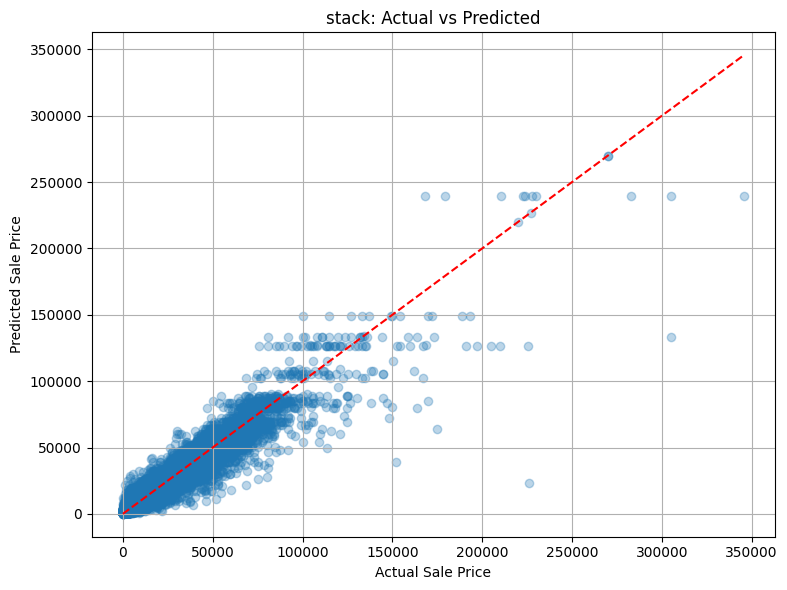

In [71]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('stack: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

In [168]:
import joblib
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from scipy.optimize import nnls

# ============================================================
# CONFIG
# ============================================================
TARGET = "VRSALEAMT"
DATE_COL = "sale_date"

BUNDLE_PATH = "stack_lgbm_iso_bundle.joblib"
SCHEMA_VERSION = 2

TE_SMOOTHING = 50.0
TE_MIN_COUNT = 5          # prune ultra-rare categories (reduces noise + bundle size)
MISSING_TOKEN = "__MISSING__"

ISO_SAMPLE_MAX = 200_000  # fit iso on a sample for speed (still plenty at your scale)
RANDOM_SEED = 42

# ============================================================
# 0) SAFETY: de-dup lists (you said these lists already exist)
# ============================================================
numeric_feats      = list(pd.Index(numeric_feats).unique())      # includes te__*
categorical_feats  = list(pd.Index(categorical_feats).unique())  # low-card only (exclude high_card)
high_card          = list(pd.Index(high_card).unique())

te_cols = [f"te__{c}" for c in high_card]
missing_te_in_numeric = [c for c in te_cols if c not in numeric_feats]
if missing_te_in_numeric:
    raise ValueError(f"numeric_feats missing TE columns: {missing_te_in_numeric}")

numeric_feats_raw = [c for c in numeric_feats if not c.startswith("te__")]
numeric_feats_raw = list(pd.Index(numeric_feats_raw).unique())

# ============================================================
# 1) VALIDATE + CLEAN: sale_date + target
# ============================================================
assert DATE_COL in cars.columns, f"{DATE_COL} missing—did you run clean_and_fix_temporal()?"
if not np.issubdtype(cars[DATE_COL].dtype, np.datetime64):
    cars = cars.copy()
    cars[DATE_COL] = pd.to_datetime(cars[DATE_COL], errors="coerce")

cars = cars.dropna(subset=[DATE_COL]).sort_values(DATE_COL)

cars = cars.copy()
cars[TARGET] = pd.to_numeric(cars[TARGET], errors="coerce")
cars = cars.dropna(subset=[TARGET])
# Optional: if 0 / negative sale amounts are invalid in your business logic, keep this:
cars = cars[cars[TARGET] > 0]

# ============================================================
# 2) TIME SPLIT: train / valid / test (prevents calibration leakage)
# ============================================================
q90 = cars[DATE_COL].quantile(0.90)
q95 = cars[DATE_COL].quantile(0.95)

train_mask = cars[DATE_COL] < q90
valid_mask = (cars[DATE_COL] >= q90) & (cars[DATE_COL] < q95)
test_mask  = cars[DATE_COL] >= q95

print("Train range:", cars.loc[train_mask, DATE_COL].min(), "→", cars.loc[train_mask, DATE_COL].max())
print("Valid range:", cars.loc[valid_mask, DATE_COL].min(), "→", cars.loc[valid_mask, DATE_COL].max())
print("Test  range:", cars.loc[test_mask,  DATE_COL].min(), "→", cars.loc[test_mask,  DATE_COL].max())
print("Sizes:", int(train_mask.sum()), int(valid_mask.sum()), int(test_mask.sum()))

# ============================================================
# 3) TARGET ENCODING (TE): fit on train only; apply everywhere
# ============================================================
def fit_te_maps(
    X_train_raw: pd.DataFrame,
    y_train: pd.Series,
    high_card: list,
    smoothing: float = 50.0,
    min_count: int = 1,
    missing_token: str = "__MISSING__",
) -> dict:
    te_maps = {}
    y_train = pd.to_numeric(y_train, errors="coerce").astype("float64")
    global_mean = float(np.nanmean(y_train))

    for col in high_card:
        if col not in X_train_raw.columns:
            te_maps[col] = {"global_mean": global_mean, "mapping": {}}
            continue

        tmp = pd.DataFrame({"col": X_train_raw[col].astype("object"), "y": y_train})
        tmp["col"] = tmp["col"].fillna(missing_token)

        stats = tmp.groupby("col")["y"].agg(["count", "mean"])
        # prune ultra-rare categories (less noise + smaller bundle)
        if min_count > 1:
            stats = stats[stats["count"] >= min_count]

        te = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
        te_maps[col] = {"global_mean": global_mean, "mapping": te.to_dict()}

    return te_maps

def apply_te_maps(
    df: pd.DataFrame,
    te_maps: dict,
    high_card: list,
    missing_token: str = "__MISSING__",
) -> pd.DataFrame:
    df = df.copy()
    for col in high_card:
        g = float(te_maps[col]["global_mean"])
        m = te_maps[col]["mapping"]
        out_col = f"te__{col}"

        if col not in df.columns:
            df[out_col] = g
        else:
            s = df[col].astype("object").fillna(missing_token)
            df[out_col] = s.map(m).fillna(g)

        df[out_col] = pd.to_numeric(df[out_col], errors="coerce").fillna(g).astype("float32")
    return df

def make_features(
    df_raw: pd.DataFrame,
    te_maps: dict,
    high_card: list,
    numeric_feats: list,
    categorical_feats: list,
) -> pd.DataFrame:
    tmp = apply_te_maps(df_raw, te_maps, high_card, missing_token=MISSING_TOKEN)

    needed = list(pd.Index(numeric_feats + categorical_feats).unique())
    missing = [c for c in needed if c not in tmp.columns]
    if missing:
        raise KeyError(f"make_features missing columns: {missing}")

    X = tmp[needed].copy()

    for c in numeric_feats:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")

    for c in categorical_feats:
        X[c] = X[c].astype("object")

    return X

# build raw frames (must include high_card originals so TE can be applied)
raw_cols_needed = list(pd.Index(numeric_feats_raw + categorical_feats + high_card).unique())

X_train_raw = cars.loc[train_mask, raw_cols_needed].copy()
y_train_raw = cars.loc[train_mask, TARGET].copy()

X_valid_raw = cars.loc[valid_mask, raw_cols_needed].copy()
y_valid_raw = cars.loc[valid_mask, TARGET].copy()

X_test_raw  = cars.loc[test_mask,  raw_cols_needed].copy()
y_test_raw  = cars.loc[test_mask,  TARGET].copy()

# fit TE on train only
te_maps = fit_te_maps(
    X_train_raw,
    y_train_raw,
    high_card=high_card,
    smoothing=TE_SMOOTHING,
    min_count=TE_MIN_COUNT,
    missing_token=MISSING_TOKEN,
)

X_train_for_model = make_features(X_train_raw, te_maps, high_card, numeric_feats, categorical_feats)
X_valid_for_model = make_features(X_valid_raw, te_maps, high_card, numeric_feats, categorical_feats)
X_test_for_model  = make_features(X_test_raw,  te_maps, high_card, numeric_feats, categorical_feats)

# index alignment guards
assert X_train_for_model.index.equals(y_train_raw.index)
assert X_valid_for_model.index.equals(y_valid_raw.index)
assert X_test_for_model.index.equals(y_test_raw.index)

# ============================================================
# 4) FIT THE TWO PRODUCTION MODELS
#   These must already exist in your notebook exactly:
stack_log_model = with_log_target(stacking_pipeline)
raw_model = Pipeline([('preproc', preprocessor), ('lgb', LGBMRegressor(**best_lgbm_params))])
# ============================================================
stack_log_model.fit(X_train_for_model, y_train_raw)
raw_model.fit(X_train_for_model, y_train_raw)

# ============================================================
# 5) FIT BLEND WEIGHTS + ISOTONIC ON VALID ONLY
# ============================================================
p_stack_valid = stack_log_model.predict(X_valid_for_model)
p_raw_valid   = raw_model.predict(X_valid_for_model)

P_valid = np.column_stack([p_stack_valid, p_raw_valid]).astype("float64")
y_valid = y_valid_raw.to_numpy(dtype="float64").ravel()

w, _ = nnls(P_valid, y_valid)
w = w / w.sum() if w.sum() > 0 else np.array([1.0, 0.0], dtype="float64")

p_blend_valid = (P_valid @ w).astype("float64")

iso = IsotonicRegression(out_of_bounds="clip")
# fit isotonic on a sample for speed/stability (still large)
n = len(p_blend_valid)
rs = np.random.RandomState(RANDOM_SEED)
if n > ISO_SAMPLE_MAX:
    idx = rs.choice(n, size=ISO_SAMPLE_MAX, replace=False)
    iso.fit(p_blend_valid[idx], y_valid[idx])
else:
    iso.fit(p_blend_valid, y_valid)

# ============================================================
# 6) EVALUATE ON TEST (UNTOUCHED) — OPTIONAL BUT RECOMMENDED
# ============================================================
def predict_bundle_internal(X_for_model: pd.DataFrame) -> np.ndarray:
    p1 = stack_log_model.predict(X_for_model)
    p2 = raw_model.predict(X_for_model)
    p  = np.column_stack([p1, p2]).astype("float64") @ w
    return iso.predict(p)

p_test = predict_bundle_internal(X_test_for_model)
y_test = y_test_raw.to_numpy(dtype="float64")

mae  = float(np.mean(np.abs(p_test - y_test)))
rmse = float(np.sqrt(np.mean((p_test - y_test) ** 2)))
mape = float(np.mean(np.abs((p_test - y_test) / np.maximum(y_test, 1.0))))  # avoid div-by-0
print(f"TEST  MAE={mae:,.0f}  RMSE={rmse:,.0f}  MAPE={mape*100:,.2f}%")
print("Blend weights:", w)

# ============================================================
# 7) SAVE LEAN BUNDLE + PREDICT HELPER
# ============================================================
def predict_from_bundle(df_raw: pd.DataFrame, bundle: dict) -> np.ndarray:
    # schema check
    missing = [c for c in bundle["raw_cols_needed"] if c not in df_raw.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    X = make_features(
        df_raw[bundle["raw_cols_needed"]],
        bundle["te_maps"],
        bundle["high_card"],
        bundle["numeric_feats"],
        bundle["categorical_feats"],
    )

    p1 = bundle["stack_model"].predict(X)
    p2 = bundle["lgbm_model"].predict(X)
    p  = (np.column_stack([p1, p2]).astype("float64") @ bundle["blend_w"]).astype("float64")
    return bundle["iso"].predict(p)

bundle = {
    "target": TARGET,
    "date_col": DATE_COL,
    "schema_version": SCHEMA_VERSION,

    "raw_cols_needed": raw_cols_needed,
    "high_card": high_card,
    "numeric_feats": numeric_feats,
    "categorical_feats": categorical_feats,

    "te_smoothing": TE_SMOOTHING,
    "te_min_count": TE_MIN_COUNT,
    "missing_token": MISSING_TOKEN,
    "te_maps": te_maps,

    "stack_model": stack_log_model,
    "lgbm_model": raw_model,
    "blend_w": w.astype("float64"),
    "iso": iso,

    "split_info": {
        "train_rows": int(train_mask.sum()),
        "valid_rows": int(valid_mask.sum()),
        "test_rows":  int(test_mask.sum()),
        "train_start": str(cars.loc[train_mask, DATE_COL].min()),
        "train_end":   str(cars.loc[train_mask, DATE_COL].max()),
        "valid_start": str(cars.loc[valid_mask, DATE_COL].min()),
        "valid_end":   str(cars.loc[valid_mask, DATE_COL].max()),
        "test_start":  str(cars.loc[test_mask,  DATE_COL].min()),
        "test_end":    str(cars.loc[test_mask,  DATE_COL].max()),
    },
    "test_metrics": {"mae": mae, "rmse": rmse, "mape": mape},
}

joblib.dump(bundle, BUNDLE_PATH, compress=3)
print(f"Saved: {BUNDLE_PATH}")

Train range: 2019-01-02 00:00:00 → 2025-07-28 00:00:00
Valid range: 2025-07-29 00:00:00 → 2025-11-12 00:00:00
Test  range: 2025-11-13 00:00:00 → 2026-03-13 00:00:00
Sizes: 4268818 236266 240637
TEST  MAE=1,501  RMSE=2,683  MAPE=31.00%
Blend weights: [0.9571692 0.0428308]
Saved: stack_lgbm_iso_bundle.joblib


In [72]:
# 9) OPTIONAL: LIGHT OPTUNA TUNING OF META (Ridge alpha + passthrough)
# ==================================================

RUN_OPTUNA = False   # flip to True if you want to run this

if RUN_OPTUNA:
    # Use a smaller subset for speed, if dataset is huge
    SUB_FRAC = 0.25
    if len(X_train) > 200_000:
        sub_idx = np.random.RandomState(42).choice(
            np.arange(len(X_train)), size=int(len(X_train)*SUB_FRAC), replace=False
        )
        X_tune = X_train.iloc[sub_idx]
        y_tune = y_train.iloc[sub_idx]
    else:
        X_tune, y_tune = X_train, y_train

    def optuna_objective(trial):
        alpha = trial.suggest_float("alpha", 1e-3, 1e2, log=True)
        passthrough = trial.suggest_categorical("passthrough", [True, False])

        meta_tuned = make_pipeline(
            StandardScaler(with_mean=False),
            Ridge(alpha=alpha, random_state=42)
        )

        stack_tuned = StackingRegressor(
            estimators=[('cat', catboost_model), ('xgb', xgb_model)],
            final_estimator=meta_tuned,
            passthrough=passthrough,
            cv=3,
            n_jobs=1
        )

        pipe_tuned = Pipeline([
            ('preproc', preprocessor),
            ('stack', stack_tuned),
        ])

        est = with_log_target(pipe_tuned)

        # 3-fold CV on tuning subset, optimize RMSE
        scores = cross_val_score(
            est, X_tune, y_tune,
            cv=3,
            scoring="neg_root_mean_squared_error",
            n_jobs=1
        )
        
        return -scores.mean()  # minimize RMSE

    sampler = TPESampler(seed=42, multivariate=True, group=True)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(optuna_objective, n_trials=30, show_progress_bar=True)

    print("\n=== OPTUNA META TUNING RESULTS ===")
    print(f"Best CV RMSE: {study.best_value:.4f}")
    print("Best params:", study.best_params)
    # You can then plug study.best_params["alpha"], ["passthrough"] back into the
    # meta and stack definitions above and re-run the fit/blend/calibration steps.


In [73]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
import numpy as np

def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

def model_metrics(name, y_true, y_hat):
    return {
        "model": name,
        "R2": r2_score(y_true, y_hat),
        "MAE": mean_absolute_error(y_true, y_hat),
        "RMSE": rmse(y_true, y_hat),
        "MAPE": mean_absolute_percentage_error(y_true, y_hat),
    }

rows_test = []
rows_test.append(model_metrics("XGBoost",              y_test, xgb_predictions))
rows_test.append(model_metrics("CatBoost (pipeline)",  y_test, catboost_preds))
# rows_test.append(model_metrics("CatBoost (native)",    y_test, cat_preds))
rows_test.append(model_metrics("Stack + LGBM blend",   y_test, y_pred))

metrics_test_df = pd.DataFrame(rows_test)
print("\n=== TEST SET METRICS (Time-based holdout) ===")
print(metrics_test_df.sort_values("RMSE"))


=== TEST SET METRICS (Time-based holdout) ===
                 model        R2          MAE         RMSE      MAPE
2   Stack + LGBM blend  0.947941  1497.481749  2639.316172  0.296199
0              XGBoost  0.946294  1504.312622  2680.733575  0.291457
1  CatBoost (pipeline)  0.937507  1570.197934  2891.736806  0.294820


Final Model Evaluation

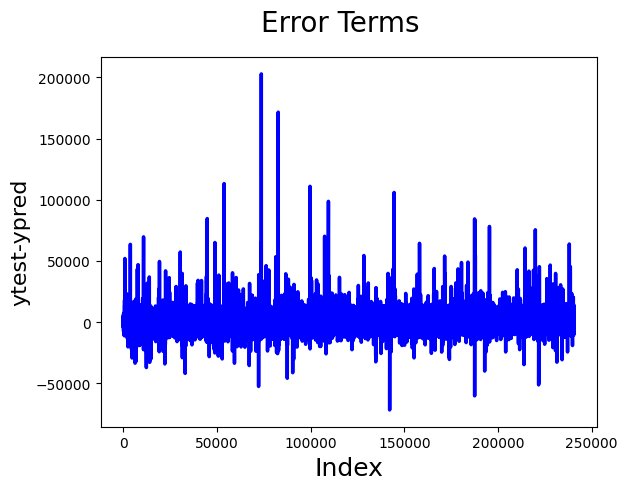

In [75]:
# Error terms
c = [i for i in range(len(y_pred))]
fig = plt.figure()
plt.plot(c,y_test-y_pred, color="blue", linewidth=2.5, linestyle="-")
fig.suptitle('Error Terms', fontsize=20)              # Plot heading 
plt.xlabel('Index', fontsize=18)                      # X-label
plt.ylabel('ytest-ypred', fontsize=16)                # Y-label
plt.show()

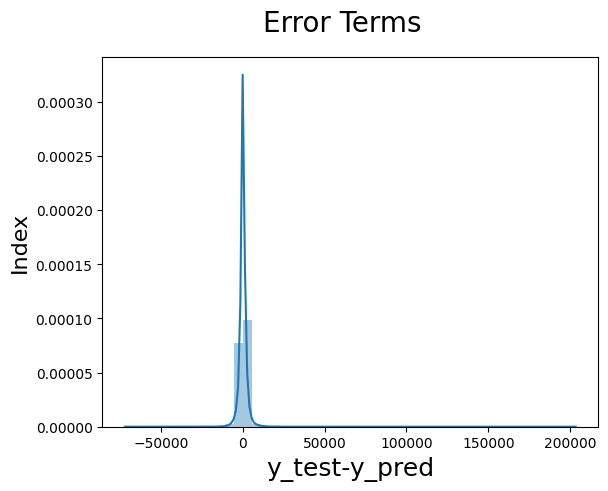

In [76]:
# Plotting the error terms to understand the distribution.
fig = plt.figure()
sns.distplot((y_test-y_pred),bins=50)
fig.suptitle('Error Terms', fontsize=20)                  # Plot heading 
plt.xlabel('y_test-y_pred', fontsize=18)                  # X-label
plt.ylabel('Index', fontsize=16)                          # Y-label
plt.show()

Export the Predictions

In [77]:
# 1) Extract the true y values for X_external
y_external = cars_test['VRSALEAMT']

# 2) Compute R² for each model
r2_xgb      = r2_score(y_external, xgb_predictions_external)
r2_catboost = r2_score(y_external, catboost_preds_external)
r2_Cat_Native = r2_score(y_external, cat_preds_external)
r2_stack    = r2_score(y_external, y_pred_external)

# 3) Print results
print(f"XGBoost external R²:      {r2_xgb:.4f}")
print(f"CatBoost external R²:     {r2_catboost:.4f}")
print(f"CatBoost Native R²:     {r2_Cat_Native:.4f}")
print(f"Stacked model external R²:{r2_stack:.4f}")

XGBoost external R²:      0.9262
CatBoost external R²:     0.9226
CatBoost Native R²:     0.9237
Stacked model external R²:0.9276


In [78]:
rows_ext = []
rows_ext.append(model_metrics("XGBoost",              y_external, xgb_predictions_external))
rows_ext.append(model_metrics("CatBoost (pipeline)",  y_external, catboost_preds_external))
rows_ext.append(model_metrics("CatBoost (native)",    y_external, cat_preds_external))
rows_ext.append(model_metrics("Stack + LGBM blend",   y_external, y_pred_external))

metrics_ext_df = pd.DataFrame(rows_ext)
print("\n=== EXTERNAL SET METRICS (True held-out customers) ===")
print(metrics_ext_df.sort_values("RMSE"))


=== EXTERNAL SET METRICS (True held-out customers) ===
                 model        R2          MAE         RMSE      MAPE
3   Stack + LGBM blend  0.927634  1279.703497  2238.341521  0.316231
0              XGBoost  0.926174  1290.563110  2260.806383  0.308678
2    CatBoost (native)  0.923716  1321.655348  2298.134876  0.324597
1  CatBoost (pipeline)  0.922569  1342.200450  2315.348982  0.320831


In [79]:
# # Create a DataFrame with the original prices and the predicted sales prices
# result_df = pd.DataFrame({
#     'SoldPrice': y_test,  # Original prices from y_test
#     'XGB_Predictions': xgb_predictions,
#     'RF_Predictions': rf_predictions,
#     'Stacked_Predictions': y_pred
# })
1
result_df = pd.DataFrame({
    'XGB_Predictions': xgb_predictions_external,
    'CatBoost_Predictions': catboost_preds_external,
    # 'CatBoost_Native_Predictions': cat_preds_external,
    'Stacked_Predictions': y_pred_external,
})

final_df = pd.concat([cars_test_original.reset_index(drop=True), result_df.reset_index(drop=True)], axis=1)

# Export the DataFrame to a CSV file
final_df.to_excel('AAA Test.xlsx', sheet_name='sheet 1', index=False)

In [80]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
import numpy as np

def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

def metrics_row(name, y_true, y_hat):
    return {
        "model": name,
        "R2": r2_score(y_true, y_hat),
        "MAE": mean_absolute_error(y_true, y_hat),
        "RMSE": rmse(y_true, y_hat),
        "MAPE": mean_absolute_percentage_error(y_true, y_hat),
    }

# --- Baseline 1: Global median ---
global_median = y_train.median()
baseline1_pred = np.full_like(y_test, fill_value=global_median, dtype=float)

# --- Baseline 2: Mean by (Make, Model, Year) ---
key_cols2 = ["Make", "Model", "Vehicle_year"]
train_keys2 = cars.loc[train_mask, key_cols2].copy()
test_keys2  = cars.loc[test_mask,  key_cols2].copy()

group_mean2 = (
    pd.concat([train_keys2, y_train.reset_index(drop=True)], axis=1)
      .groupby(key_cols2)["VRSALEAMT"].mean()
)

baseline2_pred = test_keys2.merge(
    group_mean2.rename("group_mean"),
    left_on=key_cols2,
    right_index=True,
    how="left"
)["group_mean"].fillna(global_median).to_numpy()

# --- Baseline 3: Mean by (Make, Model, Year, Trim) ---
key_cols3 = ["Make", "Model", "Vehicle_year", "Trim"]
train_keys3 = cars.loc[train_mask, key_cols3].copy()
test_keys3  = cars.loc[test_mask,  key_cols3].copy()

group_mean3 = (
    pd.concat([train_keys3, y_train.reset_index(drop=True)], axis=1)
      .groupby(key_cols3)["VRSALEAMT"].mean()
)

baseline3_pred = test_keys3.merge(
    group_mean3.rename("group_mean"),
    left_on=key_cols3,
    right_index=True,
    how="left"
)["group_mean"].fillna(global_median).to_numpy()

# --- Your existing models on TEST ---
rows = []
rows.append(metrics_row("Baseline: global median",       y_test, baseline1_pred))
rows.append(metrics_row("Baseline: Make-Model-Year",     y_test, baseline2_pred))
rows.append(metrics_row("Baseline: Make-Model-Year-Trim",y_test, baseline3_pred))

rows.append(metrics_row("XGBoost tuned",                 y_test, xgb_predictions))
rows.append(metrics_row("CatBoost pipeline",             y_test, catboost_preds))
rows.append(metrics_row("CatBoost native",               y_test, cat_preds))
rows.append(metrics_row("Stack + LGBM + isotonic",       y_test, y_pred))  # your final

metrics_test_df = pd.DataFrame(rows)
print("\n=== TEST SET PERFORMANCE COMPARISON ===")
print(metrics_test_df.sort_values("RMSE"))


=== TEST SET PERFORMANCE COMPARISON ===
                            model        R2          MAE          RMSE  \
6         Stack + LGBM + isotonic  0.947941  1497.481749   2639.316172   
3                   XGBoost tuned  0.946294  1504.312622   2680.733575   
5                 CatBoost native  0.938497  1573.395679   2868.745665   
4               CatBoost pipeline  0.937507  1570.197934   2891.736806   
1       Baseline: Make-Model-Year -0.054539  8072.784180  11878.834960   
2  Baseline: Make-Model-Year-Trim -0.100130  8218.399414  12132.898747   
0         Baseline: global median -0.141551  7565.562933  12359.198976   

       MAPE  
6  0.296199  
3  0.291457  
5  0.302653  
4  0.294820  
1  2.650563  
2  2.653444  
0  1.693746  


In [81]:
best_baseline_rmse = metrics_test_df[metrics_test_df['model'].str.startswith("Baseline")]["RMSE"].min()
best_model_rmse    = metrics_test_df.query("model == 'Stack + LGBM + isotonic'")["RMSE"].iloc[0]

improvement_pct = 100 * (best_baseline_rmse - best_model_rmse) / best_baseline_rmse
print(f"\nFinal model RMSE improvement over best baseline: {improvement_pct:.1f}%")


Final model RMSE improvement over best baseline: 77.8%


In [82]:
cols_sort = ["Make", "Model", "Trim", "Series", "VRLOCATION","VRMILEAGE", "Vehicle_condition_overall"]
cols_show = cols_sort + ["VRSALEAMT"]

cars_sorted = cars.sort_values(cols_sort, ascending=True).reset_index(drop=True)
cars_top = cars_sorted.head(10).copy()

# 1) Make pandas print wide tables without wrapping
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

# 2) Force a single-block text table
print(cars_top[cols_show].to_string(index=False))

                Make Model                   Trim  Series      VRLOCATION  VRMILEAGE  Vehicle_condition_overall  VRSALEAMT
A.P.C. MOTOR COMPANY  None                Unknown Unknown        LASVEGAS     8336.0                   4.000000     4900.0
               ACURA   ADX                    ADX Unknown  CENTRALHOUSTON     5139.0                   5.000000    28250.0
               ACURA   ADX             ADX A-Spec Unknown AUCTIONINMOTION     3489.0                   3.758885    31800.0
               ACURA   ADX ADX AWD A-Spec Advance Unknown AUCTIONINMOTION      419.0                   3.758885    36200.0
               ACURA    CL                    2.3 Unknown          AUSTIN   216014.0                   2.634932      600.0
               ACURA    CL                    2.3 Unknown     BADGERSTATE   378779.0                   2.634932      225.0
               ACURA    CL                    2.3 Unknown      CHARLESTON   203154.0                   2.634932      600.0
               A

In [83]:
cars_all = cars.copy()

# Define “near-duplicate” with broader keys + band
cars_all["mileage_band"] = (cars_all["VRMILEAGE"] // 10_000) * 10_000
group_cols = ["Make", "Model", "Vehicle_year", "Trim", "mileage_band","VRLOCATION"]

noise_all = (
    cars_all
    .groupby(group_cols)["VRSALEAMT"]
    .agg(
        count  = "count",
        mean   = "mean",
        std    = "std",
        min    = "min",
        max    = "max",
        spread = lambda s: s.max() - s.min()
    )
    .reset_index()
)

noise_all = noise_all[noise_all["count"] >= 2].dropna(subset=["std"])

print("Groups with ≥2 near-duplicate cars:", len(noise_all))

if not noise_all.empty:
    noise_floor = noise_all["std"].median()
    print("\n=== Noise summary (all cars) ===")
    print("Median within-group price std (≈ noise RMSE):", noise_floor)
    print("Mean within-group price std               :", noise_all["std"].mean())
    print("Median within-group price spread (max-min):", noise_all["spread"].median())
    print("90th percentile std                       :", noise_all["std"].quantile(0.9))

Groups with ≥2 near-duplicate cars: 828427

=== Noise summary (all cars) ===
Median within-group price std (≈ noise RMSE): 1425.07309754038
Mean within-group price std               : 2042.9884058945959
Median within-group price spread (max-min): 2700.0
90th percentile std                       : 4382.160806421112
